# Taller CNN — AAIV 2026-II · MIAA-MCD
## Detección de somnolencia + localización del conductor

**Integrantes (2):**
- Luis Manuel Rojas Correa
- Dartunduaga (nombre completo)

**Competencia Kaggle:** [aaiv-2026-ii-taller-cnn-miaa-mcd](https://www.kaggle.com/competitions/aaiv-2026-ii-taller-cnn-miaa-mcd)

**Métricas oficiales:** Accuracy (clasificación) · Dice coefficient (bbox regression, con Dice = 2·IoU/(1+IoU)).

---

### Pipeline (columna vertebral)

```
§1 Setup ─▶ §2 EDA ─▶ §3 Split (nested) ─▶ §4 Dataset+albumentations
                                                    │
                         §5 Metrics/losses ◀────────┤
                         §6 CustomCNN               │
                         §7 build_pretrained() ─────┤
                                                    ▼
                         §8 train_one_config(cfg)  ← CORAZÓN reutilizable
                                                    │
                         §9 Experiments tracker  ◀──┤
                                                    ▼
        ┌───────────────┬───────────────┬───────────┼──────────────┐
        ▼               ▼               ▼           ▼              ▼
  §10 P1 CNN       §11 P2+3          §12 P4       §13 P5         §14 P6
  custom desde     hyperparam        augment      transfer       best +
  cero             sweeps ≥3         ablation     learning       interpret.
                                                                      │
                                                            §15 Inference+TTA+submission
```

### Directrices del taller (guían cada decisión)

1. **Fundamentar** cada decisión con papers / libros / docs oficiales / notebooks Kaggle.
2. **Comparar variantes** — no basta un modelo, la rúbrica exige comparación.
3. **Librerías oficiales** (`torch`, `torchvision`, `timm`, `albumentations`) — sin reinventar.
4. **Pipeline mantenible** — `train_one_config(cfg)` es la abstracción central.
5. **Reusar contexto** — ver [`docs/pipeline_design.md`](docs/pipeline_design.md) para el detalle completo del diseño.

---
## §1. Setup — imports, semilla, config global

**Fundamento:** reproducibilidad (semilla fija en todo el pipeline) + config centralizada (directriz 4).

In [1]:
import os, sys, random, json, time, math, warnings
from pathlib import Path
from typing import Tuple, List, Dict, Callable, Optional
from dataclasses import dataclass, field, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import models
from torchvision.ops import generalized_box_iou_loss, box_iou

import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GroupShuffleSplit
)
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# --- Semilla fija para reproducibilidad ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Rutas ---
ROOT = Path('.').resolve()
DATA_DIR = ROOT / 'data'
IMG_DIR  = DATA_DIR / 'images'
OUT_DIR  = ROOT / 'outputs'; OUT_DIR.mkdir(exist_ok=True)
CKPT_DIR = ROOT / 'checkpoints'; CKPT_DIR.mkdir(exist_ok=True)

# --- Flag maestro: correr o no los experimentos pesados de §11-15 ---
# False (default): al hacer "Run All" solo corre §10 baseline (~5 min).
# True: corre todos los experimentos de §11 (barridos hyperparam), §12 (aug ablation),
#       §13 (3 backbones), §14 (k-fold sobre top-3), §15 (inference).
#       Total estimado en CPU: ~2-3 horas.
# El compañero pone True cuando quiera reproducir todo end-to-end.
RUN_HEAVY_EXPERIMENTS = False

# --- Flag secundario: §16 optimizaciones avanzadas (full-finetune + ensemble + pseudo-label) ---
# Independiente de RUN_HEAVY_EXPERIMENTS. Requiere que §13 haya corrido antes
# (los checkpoints p5_*.pt en disco, o cargados desde experiments_log.json).
RUN_OPTIMIZATION = True

# --- Constantes del problema ---
IMG_W, IMG_H = 1920, 1080
CLASSES = ['awake', 'drowsy']  # orden fijo: awake=0, drowsy=1
N_CLASSES = len(CLASSES)
CLS2IDX = {c: i for i, c in enumerate(CLASSES)}
IDX2CLS = {i: c for c, i in CLS2IDX.items()}

# --- Stats de normalización ---
# ImageNet stats — usar CON backbones preentrenados (mantiene warm-start)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
# Stats del train (calculadas en tools/eda) — usar con CustomCNN from scratch
TRAIN_MEAN = [0.4752, 0.4592, 0.4563]
TRAIN_STD  = [0.2500, 0.2351, 0.2157]

print(f"PyTorch    : {torch.__version__}")
print(f"torchvision: {torchvision.__version__}")
print(f"albumentat.: {A.__version__}")
print(f"timm       : {timm.__version__}")
print(f"Device     : {DEVICE}")
print(f"Root       : {ROOT}")

PyTorch    : 2.13.0+cu130
torchvision: 0.28.0+cu130
albumentat.: 2.0.8
timm       : 1.0.28
Device     : cpu
Root       : /home/luisrojas/Documents/universidad/IA/CompetenciaKaggle/MIA-RetoKaggle-Lrojas-Dartunduaga


---
## §2. EDA — Exploración de datos

Detalle completo en [`docs/pipeline_design.md`](docs/pipeline_design.md). Aquí solo se reproducen
los hallazgos clave para dejar constancia en las output cells.

In [2]:
df_train = pd.read_csv(DATA_DIR / 'train.csv')
df_test  = pd.read_csv(DATA_DIR / 'test.csv')
df_sub   = pd.read_csv(DATA_DIR / 'sample_submission.csv')

print(f"Train: {df_train.shape}  |  Test: {df_test.shape}  |  Sample submission: {df_sub.shape}")
print("\n--- Train head ---")
print(df_train.head())

Train: (420, 6)  |  Test: (106, 1)  |  Sample submission: (106, 6)

--- Train head ---
                                            filename   class  xmin  ymin  \
0  GOPR0492_MP4-230_jpg.rf.714121132f1b17cd0eadb6...  drowsy   792   380   
1  GOPR0492_MP4-488_jpg.rf.2971b413da07f25d05ba44...   awake   857   432   
2  GOPR0492_MP4-220_jpg.rf.564cb5e6e87965c6186c78...  drowsy   812   393   
3  GOPR0492_MP4-129_jpg.rf.12bda42acd227c8b665c95...  drowsy   710   357   
4  GOPR0492_MP4-399_jpg.rf.bfa4da2e417fae945145c7...  drowsy   805   409   

   xmax  ymax  
0  1171   981  
1  1202   833  
2  1128   861  
3  1087   956  
4  1115   853  


In [3]:
# Distribución de clases y bbox
df_train['w'] = df_train.xmax - df_train.xmin
df_train['h'] = df_train.ymax - df_train.ymin
df_train['cx'] = (df_train.xmin + df_train.xmax) / 2
df_train['cy'] = (df_train.ymin + df_train.ymax) / 2
df_train['aspect'] = df_train.w / df_train.h
df_train['area_frac'] = (df_train.w * df_train.h) / (IMG_W * IMG_H)

print("Distribución de clases:")
print(df_train['class'].value_counts())
print(f"\nBbox stats:")
print(df_train[['w','h','cx','cy','aspect','area_frac']].describe().round(2))

Distribución de clases:
class
awake     240
drowsy    180
Name: count, dtype: int64

Bbox stats:
            w       h       cx      cy  aspect  area_frac
count  420.00  420.00   420.00  420.00  420.00     420.00
mean   363.68  487.85   949.21  638.04    0.75       0.09
std     50.11   66.65    82.15   35.08    0.09       0.02
min    298.00  376.00   701.00  399.00    0.59       0.06
25%    329.00  437.00   901.38  619.88    0.69       0.07
50%    349.00  468.00   943.25  634.00    0.73       0.08
75%    384.00  530.25   985.12  651.12    0.81       0.09
max    558.00  776.00  1346.00  770.00    1.04       0.20


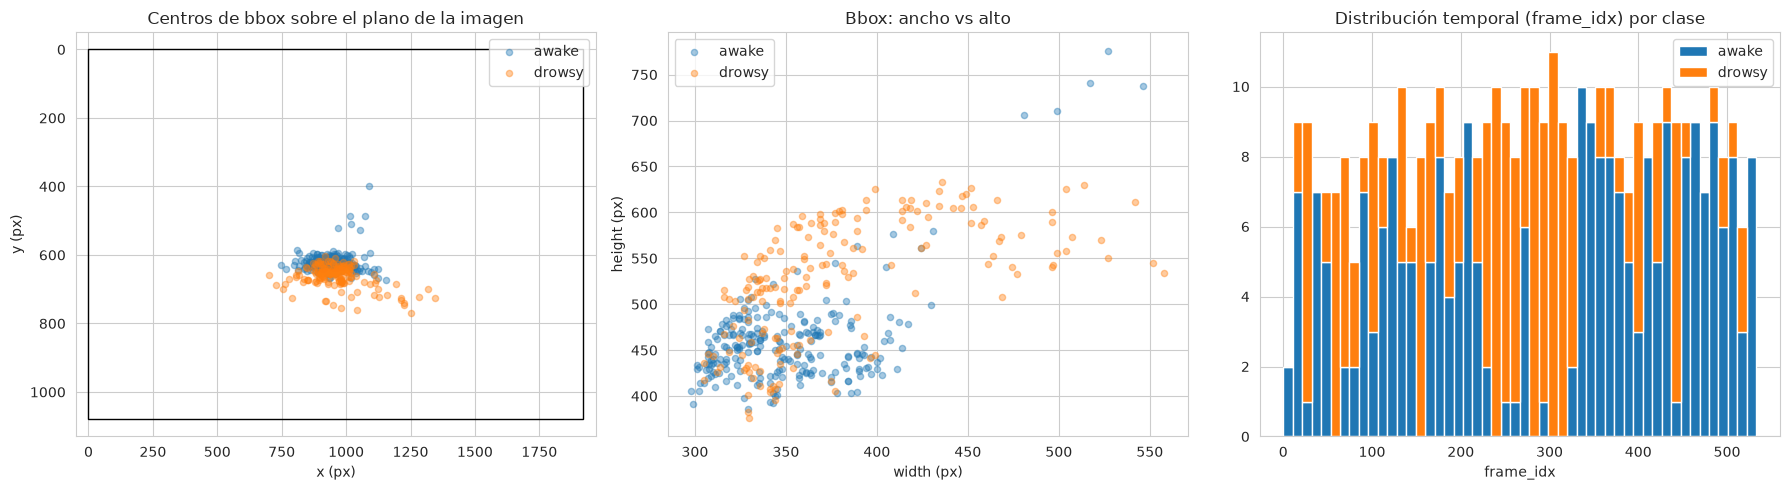

In [4]:
# Plot: centros de bbox, tamaños y distribución temporal por clase
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for cls, color in [('awake', 'C0'), ('drowsy', 'C1')]:
    sub = df_train[df_train['class'] == cls]
    axes[0].scatter(sub.cx, sub.cy, alpha=0.4, s=20, label=cls, color=color)
    axes[1].scatter(sub.w, sub.h, alpha=0.4, s=20, label=cls, color=color)

axes[0].add_patch(plt.Rectangle((0,0), IMG_W, IMG_H, fill=False, edgecolor='black'))
axes[0].set_xlim(-50, IMG_W+50); axes[0].set_ylim(IMG_H+50, -50)
axes[0].set_title('Centros de bbox sobre el plano de la imagen'); axes[0].legend()
axes[0].set_xlabel('x (px)'); axes[0].set_ylabel('y (px)')

axes[1].set_title('Bbox: ancho vs alto'); axes[1].legend()
axes[1].set_xlabel('width (px)'); axes[1].set_ylabel('height (px)')

df_train['frame_idx'] = df_train.filename.str.extract(r'MP4-(\d+)').astype(int)
awake_f = df_train[df_train['class']=='awake'].frame_idx
drowsy_f = df_train[df_train['class']=='drowsy'].frame_idx
axes[2].hist([awake_f, drowsy_f], bins=50, label=['awake','drowsy'], stacked=True)
axes[2].set_title('Distribución temporal (frame_idx) por clase'); axes[2].legend()
axes[2].set_xlabel('frame_idx')

plt.tight_layout(); plt.show()

**Hallazgos clave del EDA:**
- Imágenes 100% consistentes 1920×1080 RGB, un solo bbox por imagen, sin errores de anotación.
- Conductor **casi siempre centrado en zona central-inferior** (cx std=8.7%, cy std=5.5%).
- Ligero desbalance: awake=240 (57%), drowsy=180 (43%) → usar `class_weight`.
- **Test frames INTERLEAVED temporalmente con train** (mismo video GOPR0492) — el organizador no separó por escena, la métrica del leaderboard mide "generalización cercana".

---
## §3. Split train/val — estrategia NESTED (two-stage)

**Justificación** (ver `pipeline_design.md` §2): con 420 muestras un holdout único varía ±5-8% por sampling bias
([PMC guide](https://pmc.ncbi.nlm.nih.gov/articles/PMC10388213/), [Raschka arxiv:1811.12808](https://arxiv.org/pdf/1811.12808)).

- **Etapa exploratoria** (~15 experimentos): single stratified split 80/20 fijo (rápido y comparable).
- **Etapa final** (top-3 candidatos): StratifiedKFold k=5 sobre esos 3, promediando métricas.
- **Anti-fuga:** `stratify=y`, `random_state=SEED`. Los stats de normalización se calculan **sólo sobre train**.

In [5]:
def make_split(df: pd.DataFrame, test_size: float = 0.2, seed: int = SEED
               ) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Split estratificado por clase — devuelve (df_train, df_val) con reset_index."""
    df_tr, df_val = train_test_split(
        df, test_size=test_size, stratify=df['class'], random_state=seed
    )
    return df_tr.reset_index(drop=True), df_val.reset_index(drop=True)


def make_kfold(df: pd.DataFrame, n_splits: int = 5, seed: int = SEED):
    """Genera splits StratifiedKFold — devuelve lista de tuplas (df_train, df_val)."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    folds = []
    for tr_idx, val_idx in skf.split(df, df['class']):
        folds.append((df.iloc[tr_idx].reset_index(drop=True),
                      df.iloc[val_idx].reset_index(drop=True)))
    return folds


# --- Split principal (para exploración) ---
df_tr, df_val = make_split(df_train)
print(f"Train n={len(df_tr)}, Val n={len(df_val)}")
print("Balance clases train:", df_tr['class'].value_counts().to_dict())
print("Balance clases val  :", df_val['class'].value_counts().to_dict())

# --- Class weights para CrossEntropy (Raschka cap 6) ---
n_total = len(df_tr)
class_counts = df_tr['class'].value_counts().to_dict()
class_weights = torch.tensor(
    [n_total / (N_CLASSES * class_counts[c]) for c in CLASSES],
    dtype=torch.float32
)
print(f"\nClass weights (para CE): {dict(zip(CLASSES, class_weights.tolist()))}")

Train n=336, Val n=84
Balance clases train: {'awake': 192, 'drowsy': 144}
Balance clases val  : {'awake': 48, 'drowsy': 36}

Class weights (para CE): {'awake': 0.875, 'drowsy': 1.1666666269302368}


---
## §4. Data pipeline — Dataset + albumentations

**Decisiones:**
- **Bbox format interno:** `(cx, cy, w, h)` normalizado en [0, 1] (convención YOLO/DETR).
  Al inferir se convierte de vuelta a `(xmin, ymin, xmax, ymax)` en pixels para el CSV.
- **Albumentations** con `BboxParams(format='pascal_voc')` reescala bboxes automáticamente ante augmentations geométricas.
- **Resize** 224×224 (compatible con backbones ImageNet).
- **Normalización** por defecto `ImageNet stats` (para pretrained); pasar `use_imagenet_stats=False` para CustomCNN.

**Fuentes:** [albumentations bbox docs](https://albumentations.ai/docs/3-basic-usage/bounding-boxes-augmentations/),
Chollet cap 12 (bbox norm 0-1), Géron cap 14 (multitask heads).

In [6]:
def xyxy_to_cxcywh_norm(bbox_xyxy: List[float], img_w: int = IMG_W, img_h: int = IMG_H) -> List[float]:
    """Pascal VOC absoluto (xmin,ymin,xmax,ymax) → (cx,cy,w,h) normalizado a [0,1]."""
    x1, y1, x2, y2 = bbox_xyxy
    cx = ((x1 + x2) / 2) / img_w
    cy = ((y1 + y2) / 2) / img_h
    w  = (x2 - x1) / img_w
    h  = (y2 - y1) / img_h
    return [cx, cy, w, h]


def cxcywh_norm_to_xyxy(bbox_cxcywh_norm: torch.Tensor, img_w: int = IMG_W, img_h: int = IMG_H) -> torch.Tensor:
    """Inverso: (cx,cy,w,h) norm → (xmin,ymin,xmax,ymax) pixels. Acepta batches (N,4)."""
    cx, cy, w, h = bbox_cxcywh_norm.unbind(-1)
    x1 = (cx - w/2) * img_w
    y1 = (cy - h/2) * img_h
    x2 = (cx + w/2) * img_w
    y2 = (cy + h/2) * img_h
    return torch.stack([x1, y1, x2, y2], dim=-1)


def build_transforms(input_size: int = 224,
                     aug_level: str = 'basic',
                     use_imagenet_stats: bool = True) -> A.Compose:
    """
    aug_level: 'none' | 'basic' | 'strong'
    - none:   solo resize + normalize (baseline)
    - basic:  + HorizontalFlip + RandomBrightnessContrast (Chollet cap 8)
    - strong: + ShiftScaleRotate + HueSaturation + GaussNoise + MotionBlur
             (frames GoPro tienen ese tipo de ruido / iluminación variable)
    Referencia: albumentations docs oficiales.
    """
    mean = IMAGENET_MEAN if use_imagenet_stats else TRAIN_MEAN
    std  = IMAGENET_STD  if use_imagenet_stats else TRAIN_STD

    ops: List = []
    if aug_level in ('basic', 'strong'):
        ops.append(A.HorizontalFlip(p=0.5))
        ops.append(A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5))
    if aug_level == 'strong':
        ops.append(A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.5))
        ops.append(A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.5))
        ops.append(A.GaussNoise(var_limit=(10, 30), p=0.3))
        ops.append(A.MotionBlur(blur_limit=5, p=0.3))
    ops += [
        A.Resize(input_size, input_size),
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ]
    return A.Compose(
        ops,
        bbox_params=A.BboxParams(
            format='pascal_voc',       # trabajamos internamente en pascal_voc (xmin,ymin,xmax,ymax)
            label_fields=['class_labels'],
            min_visibility=0.3,        # descarta bbox recortadas al <30% (raro en este dataset)
        ),
    )


class DrowsyDataset(Dataset):
    """
    Dataset multitask:
      __getitem__ → (img_tensor CxHxW, label_int, bbox_cxcywh_norm (4,))

    df debe tener columnas: filename, class, xmin, ymin, xmax, ymax.
    is_test=True hace que el label y el bbox sean placeholders (para inferencia).
    """
    def __init__(self, df: pd.DataFrame, img_dir: Path,
                 transform: A.Compose, is_test: bool = False):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.is_test = is_test

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        img = cv2.imread(str(self.img_dir / row['filename']))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # OpenCV lee BGR → convertir a RGB

        if self.is_test:
            # bbox dummy centrada; será ignorada en inferencia
            bboxes = [[IMG_W*0.4, IMG_H*0.4, IMG_W*0.6, IMG_H*0.6]]
            class_labels = ['awake']
        else:
            bboxes = [[row.xmin, row.ymin, row.xmax, row.ymax]]
            class_labels = [row['class']]

        out = self.transform(image=img, bboxes=bboxes, class_labels=class_labels)
        img_t = out['image']

        if self.is_test:
            return img_t, row['filename']

        # el bbox augmentado puede quedar como lista vacía si min_visibility filtra; fallback = original
        aug_bbox = out['bboxes'][0] if out['bboxes'] else bboxes[0]
        # aug_bbox está en pascal_voc RELATIVO al tamaño del resize (después de A.Resize)
        # tenemos que reescalar a coords en la imagen resizeada; A.Resize ya ajusta el bbox.
        # Convertimos a cxcywh normalizado usando el tamaño de la imagen resizeada.
        H, W = img_t.shape[-2:]  # C,H,W tensor
        cxcywh_norm = torch.tensor(
            xyxy_to_cxcywh_norm(list(aug_bbox), img_w=W, img_h=H),
            dtype=torch.float32,
        )
        label = torch.tensor(CLS2IDX[out['class_labels'][0]], dtype=torch.long)
        return img_t, label, cxcywh_norm


# --- Test rápido del pipeline ---
_tr_transform  = build_transforms(input_size=224, aug_level='basic', use_imagenet_stats=True)
_val_transform = build_transforms(input_size=224, aug_level='none',  use_imagenet_stats=True)
_ds = DrowsyDataset(df_tr, IMG_DIR, _tr_transform)
_img, _label, _bbox = _ds[0]
print(f"img tensor: shape={_img.shape}, dtype={_img.dtype}, range=[{_img.min():.2f}, {_img.max():.2f}]")
print(f"label     : {_label.item()} ({IDX2CLS[_label.item()]})")
print(f"bbox_norm : {_bbox.tolist()}  (cx, cy, w, h) en [0,1]")

img tensor: shape=torch.Size([3, 224, 224]), dtype=torch.float32, range=[-1.54, 2.10]
label     : 0 (awake)
bbox_norm : [0.47473958134651184, 0.5833333134651184, 0.17656248807907104, 0.45000001788139343]  (cx, cy, w, h) en [0,1]


---
## §5. Métricas + losses + EarlyStopping

**Referencias:**
- IoU: Chollet cap 12 [`chapter12_object-detection.ipynb`](references/deep-learning-with-python-notebooks/chapter12_object-detection.ipynb) L520-540.
- Dice = 2·IoU/(1+IoU) — derivación directa (los libros no lo traen explícito para bbox).
- Loss bbox estilo DETR: `1·SmoothL1 + 2·GIoU` — DETR paper (Carion et al. 2020).
- EarlyStopping: [Keras docs](https://keras.io/api/callbacks/early_stopping/), [MLM guide](https://machinelearningmastery.com/how-to-stop-training-deep-neural-networks-at-the-right-time-using-early-stopping/).

In [7]:
def bbox_iou(pred_cxcywh: torch.Tensor, true_cxcywh: torch.Tensor,
             eps: float = 1e-7) -> torch.Tensor:
    """
    IoU batched entre dos tensores (N,4) en formato (cx,cy,w,h). Todo en [0,1] o pixels indistinto.
    """
    def _to_xyxy(b):
        cx, cy, w, h = b.unbind(-1)
        return torch.stack([cx-w/2, cy-h/2, cx+w/2, cy+h/2], dim=-1)
    p, t = _to_xyxy(pred_cxcywh), _to_xyxy(true_cxcywh)
    x1 = torch.max(p[..., 0], t[..., 0])
    y1 = torch.max(p[..., 1], t[..., 1])
    x2 = torch.min(p[..., 2], t[..., 2])
    y2 = torch.min(p[..., 3], t[..., 3])
    inter = (x2 - x1).clamp(min=0) * (y2 - y1).clamp(min=0)
    area_p = (p[..., 2] - p[..., 0]) * (p[..., 3] - p[..., 1])
    area_t = (t[..., 2] - t[..., 0]) * (t[..., 3] - t[..., 1])
    union = area_p + area_t - inter + eps
    return inter / union


def bbox_dice(pred_cxcywh: torch.Tensor, true_cxcywh: torch.Tensor) -> torch.Tensor:
    """Dice coefficient = 2·IoU/(1+IoU). Monotónica en IoU."""
    iou = bbox_iou(pred_cxcywh, true_cxcywh)
    return 2 * iou / (1 + iou)


class MultitaskLoss(nn.Module):
    """
    Loss combinada: L = w_cls · CE + w_bbox · (SmoothL1 + λ_giou · GIoU_loss)
    Config default estilo DETR (SmoothL1 estable + GIoU mejora convergencia geométrica).

    label_smoothing: regulariza predicciones over-confident (Szegedy et al. 2016,
    Müller et al. 2019 https://arxiv.org/abs/1906.02629). Típico 0.05-0.1.
    """
    def __init__(self, w_cls: float = 1.0, w_bbox: float = 5.0,
                 lambda_giou: float = 2.0, class_weights: Optional[torch.Tensor] = None,
                 label_smoothing: float = 0.0):
        super().__init__()
        self.w_cls = w_cls
        self.w_bbox = w_bbox
        self.lambda_giou = lambda_giou
        self.ce = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=label_smoothing)
        self.smooth_l1 = nn.SmoothL1Loss()

    def forward(self, logits: torch.Tensor, bbox_pred: torch.Tensor,
                labels: torch.Tensor, bbox_true: torch.Tensor) -> Dict[str, torch.Tensor]:
        loss_cls = self.ce(logits, labels)
        loss_l1  = self.smooth_l1(bbox_pred, bbox_true)
        # GIoU loss requiere xyxy en pixels o en [0,1] (invariant); usamos [0,1] via cxcywh_norm
        pred_xyxy = cxcywh_norm_to_xyxy(bbox_pred, img_w=1, img_h=1)
        true_xyxy = cxcywh_norm_to_xyxy(bbox_true, img_w=1, img_h=1)
        loss_giou = generalized_box_iou_loss(pred_xyxy, true_xyxy, reduction='mean')
        loss_bbox = loss_l1 + self.lambda_giou * loss_giou
        total = self.w_cls * loss_cls + self.w_bbox * loss_bbox
        return dict(total=total, cls=loss_cls, bbox=loss_bbox, l1=loss_l1, giou=loss_giou)


class EarlyStopping:
    """
    Monitorea `val_total_loss` (o cualquier métrica escalar). patience=12 recomendada para dataset chico.
    Uso:
      es = EarlyStopping(patience=12, min_delta=1e-3, mode='min')
      for epoch in range(max_epochs):
          ...
          if es.step(val_loss):
              break
    """
    def __init__(self, patience: int = 12, min_delta: float = 1e-3, mode: str = 'min'):
        assert mode in ('min', 'max')
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best = math.inf if mode == 'min' else -math.inf
        self.counter = 0
        self.best_epoch = -1

    def step(self, value: float) -> bool:
        improved = (self.mode == 'min' and value < self.best - self.min_delta) or \
                   (self.mode == 'max' and value > self.best + self.min_delta)
        if improved:
            self.best = value
            self.counter = 0
            return False
        self.counter += 1
        return self.counter >= self.patience


# --- Sanity check de metrics ---
_bbox_true = torch.tensor([[0.5, 0.5, 0.3, 0.4]])   # cxcywh en [0,1]
_bbox_pred = torch.tensor([[0.5, 0.5, 0.3, 0.4]])
print(f"IoU(identical)  = {bbox_iou(_bbox_pred, _bbox_true).item():.4f}   (esperado 1.0)")
print(f"Dice(identical) = {bbox_dice(_bbox_pred, _bbox_true).item():.4f}  (esperado 1.0)")

_bbox_pred2 = torch.tensor([[0.6, 0.5, 0.3, 0.4]])  # desplazada
iou2 = bbox_iou(_bbox_pred2, _bbox_true).item()
dice2 = bbox_dice(_bbox_pred2, _bbox_true).item()
print(f"IoU(shifted)    = {iou2:.4f}  |  Dice(shifted) = {dice2:.4f}")

IoU(identical)  = 1.0000   (esperado 1.0)
Dice(identical) = 1.0000  (esperado 1.0)
IoU(shifted)    = 0.5000  |  Dice(shifted) = 0.6667


---
## §6. CustomCNN — Backbone desde cero (Punto 1 rúbrica)

**Arquitectura:** 4 bloques `Conv3x3(pad=1) → BN → ReLU → MaxPool2x2 → Dropout(0.5)`, canales 32→64→128→256,
seguidos de **GlobalAveragePooling** (menos parámetros que Flatten, previene overfit).

**Justificaciones citables en sustentación:**
- Kernel 3×3 padding 1: **VGG-style, Simonyan & Zisserman 2014** (arxiv:1409.1556) — bloques homogéneos.
- BatchNorm: **Ioffe & Szegedy 2015** (arxiv:1502.03167) — estabiliza gradientes, permite LR mayor.
- Dropout 0.5: **Srivastava et al. 2014** — apropiado con dataset chico.
- GAP: **Chollet cap 9**, **Lin et al. Network-in-Network 2013** (arxiv:1312.4400) — 10× menos params.
- He/Kaiming init: **Géron cap 11**, requerido por ReLU para preservar varianza.
- Basado en el patrón `ch14_part2.py:289-306` de Raschka.

In [8]:
class CustomCNN(nn.Module):
    """
    Multitask CNN from scratch:
        Input (B,3,H,W)
          → 4× [Conv3-BN-ReLU-MaxPool2-Dropout] canales 32→64→128→256
          → GlobalAvgPool
          → head_cls: Linear(256, 2)
          → head_bbox: Linear(256, 4) + Sigmoid  (bbox cxcywh normalizado a [0,1])
    """
    def __init__(self, n_classes: int = 2, dropout: float = 0.5):
        super().__init__()
        self.features = nn.Sequential(
            self._block(3,   32, dropout),
            self._block(32,  64, dropout),
            self._block(64, 128, dropout),
            self._block(128, 256, dropout),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)  # GAP → (B, 256, 1, 1)
        self.head_cls  = nn.Linear(256, n_classes)
        self.head_bbox = nn.Sequential(nn.Linear(256, 4), nn.Sigmoid())  # cxcywh en [0,1]
        self._init_weights()

    @staticmethod
    def _block(in_c: int, out_c: int, dropout: float) -> nn.Sequential:
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout),
        )

    def _init_weights(self):
        # He/Kaiming (Géron cap 11)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        feat = self.features(x)          # (B, 256, H/16, W/16)
        pooled = self.pool(feat).flatten(1)  # (B, 256)
        logits = self.head_cls(pooled)   # (B, 2)
        bbox   = self.head_bbox(pooled)  # (B, 4) en [0,1]
        return logits, bbox


# --- Sanity check ---
_model = CustomCNN()
_x = torch.randn(2, 3, 224, 224)
_logits, _bbox = _model(_x)
_n_params = sum(p.numel() for p in _model.parameters())
print(f"CustomCNN — output: logits {tuple(_logits.shape)}, bbox {tuple(_bbox.shape)}")
print(f"  params: {_n_params/1e6:.2f}M")

CustomCNN — output: logits (2, 2), bbox (2, 4)
  params: 0.39M


---
## §7. Backbones preentrenados (Punto 5 rúbrica)

**3 backbones ligeros** (más informativo que 2 profundos con 336 samples + CPU
— [Lightweight benchmark arxiv:2505.03303](https://arxiv.org/html/2505.03303v1)):

| Backbone | Params | Fuente / paper |
|---|---|---|
| `resnet18` (torchvision) | 11M | He et al. 2015 arxiv:1512.03385 |
| `mobilenet_v3_small` (torchvision) | 2.5M | Howard et al. 2019 arxiv:1905.02244 |
| `efficientnet_b0` (timm) | 5.3M | Tan & Le 2019 arxiv:1905.11946 |

**Estrategia freeze/unfreeze en 2 fases** (Chollet cap 8, [TF tutorial](https://www.tensorflow.org/tutorials/images/transfer_learning)):
- **Fase A:** backbone congelado, entrenar solo heads (~10 epochs, LR=1e-3).
- **Fase B:** descongelar último stage, LR diferencial (backbone LR = head LR / 10), otros 15-20 epochs con early stopping.

In [9]:
class MultitaskWrapper(nn.Module):
    """Backbone (feature extractor) → GAP → head_cls + head_bbox."""
    def __init__(self, backbone: nn.Module, feat_dim: int,
                 n_classes: int = 2, dropout_head: float = 0.3):
        super().__init__()
        self.backbone = backbone
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout_head)
        self.head_cls  = nn.Linear(feat_dim, n_classes)
        self.head_bbox = nn.Sequential(nn.Linear(feat_dim, 4), nn.Sigmoid())

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        feat = self.backbone(x)
        if feat.ndim == 4:
            feat = self.pool(feat).flatten(1)
        feat = self.dropout(feat)
        return self.head_cls(feat), self.head_bbox(feat)


def build_pretrained(name: str, n_classes: int = 2,
                     dropout_head: float = 0.3, freeze: bool = True) -> MultitaskWrapper:
    """
    Construye backbone preentrenado con heads multitask.
    name ∈ {'resnet18', 'mobilenet_v3_small', 'efficientnet_b0'}
    freeze: si True, backbone.parameters() se congelan (fase A).
            Para descongelar último stage (fase B) usar unfreeze_last_stage() abajo.
    """
    if name == 'resnet18':
        m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        feat_dim = m.fc.in_features
        m.fc = nn.Identity()
    elif name == 'mobilenet_v3_small':
        m = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        feat_dim = m.classifier[0].in_features
        m.classifier = nn.Identity()
    elif name == 'efficientnet_b0':
        m = timm.create_model('efficientnet_b0', pretrained=True, num_classes=0, global_pool='')
        feat_dim = m.num_features
    else:
        raise ValueError(f"Backbone desconocido: {name}. Opciones: resnet18, mobilenet_v3_small, efficientnet_b0")

    if freeze:
        for p in m.parameters():
            p.requires_grad = False

    return MultitaskWrapper(m, feat_dim=feat_dim, n_classes=n_classes, dropout_head=dropout_head)


def unfreeze_last_stage(model: MultitaskWrapper, backbone_name: str) -> None:
    """Descongela el último stage del backbone (fase B fine-tuning parcial)."""
    if backbone_name == 'resnet18':
        for p in model.backbone.layer4.parameters(): p.requires_grad = True
    elif backbone_name == 'mobilenet_v3_small':
        # Últimos 3 bloques
        for p in model.backbone.features[-3:].parameters(): p.requires_grad = True
    elif backbone_name == 'efficientnet_b0':
        for p in model.backbone.blocks[-2:].parameters(): p.requires_grad = True


# --- Sanity check de los 3 backbones ---
for name in ['resnet18', 'mobilenet_v3_small', 'efficientnet_b0']:
    m = build_pretrained(name)
    n_total = sum(p.numel() for p in m.parameters())
    n_trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    logits, bbox = m(_x)
    print(f"{name:22s}  params total={n_total/1e6:>5.2f}M  entrenables={n_trainable/1e3:>5.1f}k  "
          f"→ logits {tuple(logits.shape)}, bbox {tuple(bbox.shape)}")

resnet18                params total=11.18M  entrenables=  3.1k  → logits (2, 2), bbox (2, 4)


mobilenet_v3_small      params total= 0.93M  entrenables=  3.5k  → logits (2, 2), bbox (2, 4)


efficientnet_b0         params total= 4.02M  entrenables=  7.7k  → logits (2, 2), bbox (2, 4)


---
## §8. `train_one_config(cfg)` — CORAZÓN del pipeline

**Directriz 4:** cada experimento es una llamada a esta función con distinto `cfg` dict.
Los resultados se acumulan en `EXPERIMENTS_LOG` (§9) para el análisis final del punto 6.

In [10]:
@dataclass
class ExpConfig:
    """Config completa de un experimento. Cambiar aquí es cambiar el experimento."""
    name: str
    model_kind: str = 'custom'            # 'custom' | 'resnet18' | 'mobilenet_v3_small' | 'efficientnet_b0'
    input_size: int = 224
    batch_size: int = 32
    lr_head: float = 1e-3
    lr_backbone: float = 1e-4             # solo se usa en fase B
    weight_decay: float = 5e-4
    optimizer: str = 'adamw'              # 'adam' | 'adamw' | 'sgd'
    scheduler: str = 'cosine'             # 'cosine' | 'step' | 'none'
    bbox_loss_weight: float = 5.0
    lambda_giou: float = 2.0
    aug_level: str = 'basic'              # 'none' | 'basic' | 'strong'
    dropout_head: float = 0.3
    use_class_weights: bool = True
    freeze_epochs: int = 10                # fase A (feature extraction) — solo pretrained
    finetune_epochs: int = 20              # fase B (unfreeze last stage) — solo pretrained
    total_epochs: int = 30                 # CustomCNN entrena de una sola vez
    early_stopping_patience: int = 12
    seed: int = SEED
    num_workers: int = 0                   # 0 evita problemas de fork en nbconvert
    # --- Extensiones para §16 optimizaciones ---
    label_smoothing: float = 0.0           # 0.05-0.1 típico; regulariza confidence
    full_finetune: bool = False            # True: descongela TODO el backbone desde el inicio (skip fase A)
    lr_backbone_full: float = 2e-5         # LR muy bajo para full-finetune (backbone LR = head LR / 25)


def make_optimizer(model: nn.Module, cfg: ExpConfig, param_groups=None):
    if param_groups is None:
        param_groups = [{'params': [p for p in model.parameters() if p.requires_grad]}]
    if cfg.optimizer == 'adam':
        return torch.optim.Adam(param_groups, lr=cfg.lr_head, weight_decay=cfg.weight_decay)
    if cfg.optimizer == 'adamw':
        return torch.optim.AdamW(param_groups, lr=cfg.lr_head, weight_decay=cfg.weight_decay)
    if cfg.optimizer == 'sgd':
        return torch.optim.SGD(param_groups, lr=cfg.lr_head, momentum=0.9, weight_decay=cfg.weight_decay)
    raise ValueError(cfg.optimizer)


def make_scheduler(optimizer, cfg: ExpConfig, n_epochs: int):
    if cfg.scheduler == 'cosine':
        return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    if cfg.scheduler == 'step':
        return torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    return None


def train_epoch(model, loader, loss_fn, optimizer, device) -> Dict[str, float]:
    model.train()
    totals = dict(loss=0.0, cls=0.0, bbox=0.0, acc=0.0, dice=0.0)
    n = 0
    for img, label, bbox in loader:
        img, label, bbox = img.to(device), label.to(device), bbox.to(device)
        logits, bbox_pred = model(img)
        losses = loss_fn(logits, bbox_pred, label, bbox)
        optimizer.zero_grad()
        losses['total'].backward()
        optimizer.step()
        bs = img.size(0); n += bs
        totals['loss'] += losses['total'].item() * bs
        totals['cls']  += losses['cls'].item()   * bs
        totals['bbox'] += losses['bbox'].item()  * bs
        totals['acc']  += (logits.argmax(1) == label).float().sum().item()
        totals['dice'] += bbox_dice(bbox_pred, bbox).sum().item()
    return {k: v / n for k, v in totals.items()}


@torch.no_grad()
def eval_epoch(model, loader, loss_fn, device) -> Dict[str, float]:
    model.eval()
    totals = dict(loss=0.0, cls=0.0, bbox=0.0, acc=0.0, dice=0.0)
    n = 0
    for img, label, bbox in loader:
        img, label, bbox = img.to(device), label.to(device), bbox.to(device)
        logits, bbox_pred = model(img)
        losses = loss_fn(logits, bbox_pred, label, bbox)
        bs = img.size(0); n += bs
        totals['loss'] += losses['total'].item() * bs
        totals['cls']  += losses['cls'].item()   * bs
        totals['bbox'] += losses['bbox'].item()  * bs
        totals['acc']  += (logits.argmax(1) == label).float().sum().item()
        totals['dice'] += bbox_dice(bbox_pred, bbox).sum().item()
    return {k: v / n for k, v in totals.items()}


def train_one_config(cfg: ExpConfig,
                     df_train_split: pd.DataFrame,
                     df_val_split: pd.DataFrame,
                     verbose: bool = True) -> Dict:
    """
    Entrena un experimento entero según cfg. Devuelve dict con history + best metrics + ckpt path.
    Para pretrained: entrena en 2 fases (freeze → unfreeze last stage).
    Para CustomCNN: entrena en una sola fase de `total_epochs`.
    """
    # Reproducibilidad
    torch.manual_seed(cfg.seed); np.random.seed(cfg.seed); random.seed(cfg.seed)

    # Data
    use_imagenet_stats = (cfg.model_kind != 'custom')
    tr_tf  = build_transforms(cfg.input_size, cfg.aug_level, use_imagenet_stats)
    val_tf = build_transforms(cfg.input_size, 'none',        use_imagenet_stats)
    tr_ds  = DrowsyDataset(df_train_split, IMG_DIR, tr_tf)
    val_ds = DrowsyDataset(df_val_split,   IMG_DIR, val_tf)
    tr_ld  = DataLoader(tr_ds,  batch_size=cfg.batch_size, shuffle=True,
                        num_workers=cfg.num_workers, drop_last=True)
    val_ld = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False,
                        num_workers=cfg.num_workers)

    # Modelo
    if cfg.model_kind == 'custom':
        model = CustomCNN(dropout=cfg.dropout_head)
    else:
        model = build_pretrained(cfg.model_kind, dropout_head=cfg.dropout_head, freeze=True)
    model = model.to(DEVICE)

    # Loss
    cw = class_weights.to(DEVICE) if cfg.use_class_weights else None
    loss_fn = MultitaskLoss(
        w_cls=1.0, w_bbox=cfg.bbox_loss_weight,
        lambda_giou=cfg.lambda_giou, class_weights=cw,
        label_smoothing=cfg.label_smoothing,
    )

    history = []
    best = dict(val_loss=math.inf, val_acc=0.0, val_dice=0.0, epoch=-1)
    ckpt_path = CKPT_DIR / f"{cfg.name}.pt"

    def _run_phase(n_epochs: int, phase_label: str, opt, sched, es):
        nonlocal best
        for ep in range(n_epochs):
            tr_metrics  = train_epoch(model, tr_ld,  loss_fn, opt, DEVICE)
            val_metrics = eval_epoch (model, val_ld, loss_fn, DEVICE)
            if sched is not None:
                sched.step()
            row = dict(phase=phase_label, epoch=ep,
                       **{f'train_{k}': v for k, v in tr_metrics.items()},
                       **{f'val_{k}':   v for k, v in val_metrics.items()})
            history.append(row)
            if verbose:
                print(f"  [{phase_label} ep{ep+1:>2}/{n_epochs}] "
                      f"train loss={tr_metrics['loss']:.3f} acc={tr_metrics['acc']:.3f} dice={tr_metrics['dice']:.3f}  |  "
                      f"val loss={val_metrics['loss']:.3f} acc={val_metrics['acc']:.3f} dice={val_metrics['dice']:.3f}")
            if val_metrics['loss'] < best['val_loss']:
                best = dict(val_loss=val_metrics['loss'], val_acc=val_metrics['acc'],
                            val_dice=val_metrics['dice'], epoch=len(history)-1)
                torch.save(model.state_dict(), ckpt_path)
            if es.step(val_metrics['loss']):
                if verbose:
                    print(f"  ↳ early stopping @ep{ep+1} (patience={cfg.early_stopping_patience})")
                break

    if cfg.model_kind == 'custom':
        opt = make_optimizer(model, cfg)
        sched = make_scheduler(opt, cfg, cfg.total_epochs)
        es = EarlyStopping(patience=cfg.early_stopping_patience)
        _run_phase(cfg.total_epochs, 'train', opt, sched, es)
    elif cfg.full_finetune:
        # FULL FINETUNE — descongelar TODO desde el inicio, LR diferencial fuerte
        for p in model.backbone.parameters():
            p.requires_grad = True
        opt = torch.optim.AdamW([
            {'params': model.backbone.parameters(), 'lr': cfg.lr_backbone_full},
            {'params': list(model.head_cls.parameters()) + list(model.head_bbox.parameters()),
             'lr': cfg.lr_head},
        ], weight_decay=cfg.weight_decay)
        sched = make_scheduler(opt, cfg, cfg.finetune_epochs)
        es = EarlyStopping(patience=cfg.early_stopping_patience)
        _run_phase(cfg.finetune_epochs, 'full-ft', opt, sched, es)
    else:
        # FASE A — feature extraction (backbone congelado)
        opt_a = make_optimizer(model, cfg)  # solo params entrenables (heads)
        sched_a = make_scheduler(opt_a, cfg, cfg.freeze_epochs)
        es_a = EarlyStopping(patience=cfg.early_stopping_patience)
        _run_phase(cfg.freeze_epochs, 'A(feat)', opt_a, sched_a, es_a)
        # FASE B — unfreeze último stage + LR diferencial
        unfreeze_last_stage(model, cfg.model_kind)
        opt_b = torch.optim.AdamW([
            {'params': [p for p in model.backbone.parameters() if p.requires_grad],
             'lr': cfg.lr_backbone},
            {'params': list(model.head_cls.parameters()) + list(model.head_bbox.parameters()),
             'lr': cfg.lr_head},
        ], weight_decay=cfg.weight_decay)
        sched_b = make_scheduler(opt_b, cfg, cfg.finetune_epochs)
        es_b = EarlyStopping(patience=cfg.early_stopping_patience)
        _run_phase(cfg.finetune_epochs, 'B(fine)', opt_b, sched_b, es_b)

    return dict(
        name=cfg.name, cfg=asdict(cfg), history=history, best=best, ckpt=str(ckpt_path),
    )

---
## §9. Tracker de experimentos

Cada llamada a `train_one_config()` se guarda aquí. Al final (`§14`) se consolidan en tabla + gráfico.

In [11]:
EXPERIMENTS_LOG: List[Dict] = []


def register(result: Dict) -> None:
    EXPERIMENTS_LOG.append(result)
    # Persistir en disco MERGEANDO con lo que ya hay (no sobreescribir experimentos previos).
    json_path = OUT_DIR / 'experiments_log.json'
    existing = {}
    if json_path.exists():
        try:
            with open(json_path) as f:
                for r in json.load(f):
                    existing[r['name']] = r
        except Exception:
            pass
    # Overrides con los actuales en memoria (los nuevos ganan)
    for r in EXPERIMENTS_LOG:
        existing[r['name']] = {'name': r['name'], 'cfg': r['cfg'], 'best': r['best']}
    with open(json_path, 'w') as f:
        json.dump(list(existing.values()), f, indent=2)


def summary_df() -> pd.DataFrame:
    rows = []
    for r in EXPERIMENTS_LOG:
        rows.append({
            'name'       : r['name'],
            'model_kind' : r['cfg']['model_kind'],
            'aug_level'  : r['cfg']['aug_level'],
            'bbox_w'     : r['cfg']['bbox_loss_weight'],
            'best_epoch' : r['best']['epoch'],
            'val_loss'   : round(r['best']['val_loss'], 4),
            'val_acc'    : round(r['best']['val_acc'],  4),
            'val_dice'   : round(r['best']['val_dice'], 4),
        })
    return pd.DataFrame(rows).sort_values('val_dice', ascending=False)


def plot_history(result: Dict, ax=None):
    hist = pd.DataFrame(result['history'])
    if ax is None:
        _, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(hist.index, hist.train_loss, label='train'); ax[0].plot(hist.index, hist.val_loss, label='val')
    ax[0].set_title(f"{result['name']} — loss"); ax[0].legend(); ax[0].set_xlabel('epoch')
    ax[1].plot(hist.index, hist.train_dice, label='train'); ax[1].plot(hist.index, hist.val_dice, label='val')
    ax[1].plot(hist.index, hist.train_acc,  label='train_acc', linestyle='--')
    ax[1].plot(hist.index, hist.val_acc,    label='val_acc',   linestyle='--')
    ax[1].set_title(f"{result['name']} — metrics"); ax[1].legend(); ax[1].set_xlabel('epoch')
    plt.tight_layout()

---
## §10. [Punto 1 rúbrica — 1 pt] CNN personalizado desde cero

**Objetivo:** entrenar `CustomCNN` desde cero, evidenciar aprendizaje con curvas train/val, reportar métricas base.

### Arquitectura (repaso)

```
Input (B, 3, 224, 224)
  ↓
Bloque 1: Conv3x3(3→32)  → BN → ReLU → MaxPool2 → Dropout(0.5)   → (B,32,112,112)
Bloque 2: Conv3x3(32→64) → BN → ReLU → MaxPool2 → Dropout(0.5)   → (B,64,56,56)
Bloque 3: Conv3x3(64→128)→ BN → ReLU → MaxPool2 → Dropout(0.5)   → (B,128,28,28)
Bloque 4: Conv3x3(128→256)→BN → ReLU → MaxPool2 → Dropout(0.5)   → (B,256,14,14)
  ↓
GlobalAveragePooling → (B, 256)
  ├─ head_cls:  Linear(256, 2)                          → logits    (B, 2)
  └─ head_bbox: Linear(256, 4) + Sigmoid                → cxcywh   (B, 4) ∈ [0,1]
```

### Justificaciones (defensa en sustentación)

| Decisión | Fuente |
|---|---|
| Kernel 3×3 padding 1 (VGG-style) | Simonyan & Zisserman 2014 [arxiv:1409.1556](https://arxiv.org/abs/1409.1556) |
| BatchNorm después de cada Conv | Ioffe & Szegedy 2015 [arxiv:1502.03167](https://arxiv.org/abs/1502.03167) |
| Dropout 0.5 en cada bloque | Srivastava et al. 2014 (JMLR) |
| GlobalAvgPool (vs Flatten) | Lin et al. Network-in-Network 2013 [arxiv:1312.4400](https://arxiv.org/abs/1312.4400), Chollet cap 9 |
| He/Kaiming init para ReLU | He et al. 2015 [arxiv:1502.01852](https://arxiv.org/abs/1502.01852), Géron cap 11 |
| Patrón `Conv-BN-ReLU-Pool-Dropout` con canales 32→64→128→256 | Raschka `ch14_part2.py:289-306` |
| Normalización con stats del train (no ImageNet) | Modelo *from scratch* → sin warm-start, ver §1 |
| Bbox normalizada `(cx,cy,w,h)` en [0,1] con Sigmoid | Convención YOLO/DETR — [Ultralytics](https://github.com/ultralytics/ultralytics/issues/2005) |

### Config del experimento

In [12]:
cfg_p1 = ExpConfig(
    name='p1_custom_baseline',
    model_kind='custom',
    total_epochs=25,
    aug_level='basic',              # HorizontalFlip + RandomBrightnessContrast
    batch_size=32,
    lr_head=1e-3,
    optimizer='adamw',
    scheduler='cosine',
    bbox_loss_weight=5.0,
    lambda_giou=2.0,
    dropout_head=0.5,
    use_class_weights=True,
    early_stopping_patience=12,
    num_workers=0,
)
print("Config del baseline:")
for k, v in asdict(cfg_p1).items():
    print(f"  {k:26s} = {v}")

Config del baseline:
  name                       = p1_custom_baseline
  model_kind                 = custom
  input_size                 = 224
  batch_size                 = 32
  lr_head                    = 0.001
  lr_backbone                = 0.0001
  weight_decay               = 0.0005
  optimizer                  = adamw
  scheduler                  = cosine
  bbox_loss_weight           = 5.0
  lambda_giou                = 2.0
  aug_level                  = basic
  dropout_head               = 0.5
  use_class_weights          = True
  freeze_epochs              = 10
  finetune_epochs            = 20
  total_epochs               = 25
  early_stopping_patience    = 12
  seed                       = 42
  num_workers                = 0
  label_smoothing            = 0.0
  full_finetune              = False
  lr_backbone_full           = 2e-05


### Entrenamiento

In [13]:
t0 = time.time()
result_p1 = train_one_config(cfg_p1, df_tr, df_val, verbose=True)
print(f"\nDuración total: {(time.time()-t0)/60:.1f} min")
register(result_p1)

  [train ep 1/25] train loss=11.569 acc=0.475 dice=0.160  |  val loss=8.920 acc=0.536 dice=0.323


  [train ep 2/25] train loss=11.169 acc=0.534 dice=0.165  |  val loss=9.571 acc=0.429 dice=0.260


  [train ep 3/25] train loss=10.959 acc=0.484 dice=0.162  |  val loss=9.730 acc=0.429 dice=0.238


  [train ep 4/25] train loss=10.845 acc=0.500 dice=0.165  |  val loss=9.777 acc=0.429 dice=0.227


  [train ep 5/25] train loss=10.682 acc=0.512 dice=0.169  |  val loss=9.698 acc=0.548 dice=0.230


...

  [train ep 9/25] train loss=10.338 acc=0.456 dice=0.203  |  val loss=9.348 acc=0.429 dice=0.272


  [train ep10/25] train loss=10.318 acc=0.472 dice=0.209  |  val loss=9.193 acc=0.476 dice=0.292


  [train ep11/25] train loss=10.171 acc=0.522 dice=0.219  |  val loss=9.130 acc=0.429 dice=0.299


  [train ep12/25] train loss=10.264 acc=0.491 dice=0.230  |  val loss=9.254 acc=0.429 dice=0.284


  [train ep13/25] train loss=10.045 acc=0.491 dice=0.242  |  val loss=9.229 acc=0.429 dice=0.286
  ↳ early stopping @ep13 (patience=12)

Duración total: 2.2 min


### Curvas de aprendizaje

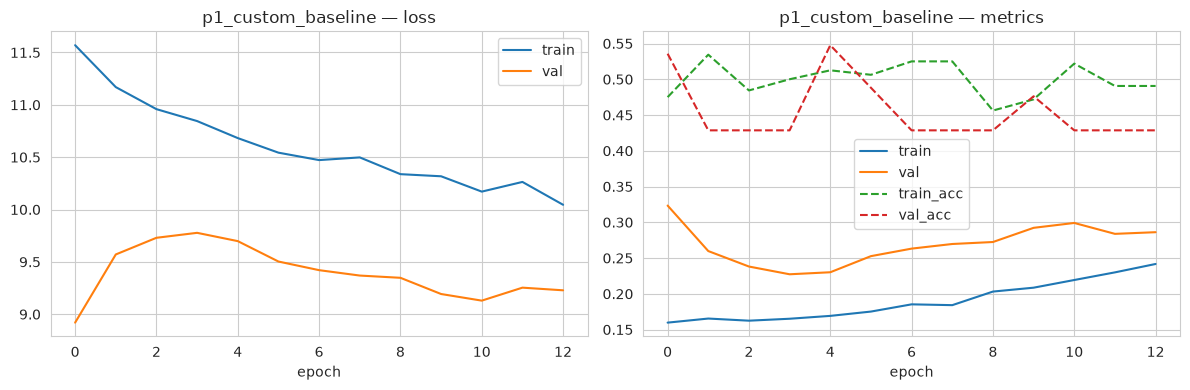

In [14]:
plot_history(result_p1)
plt.show()

### Métricas finales del baseline

In [15]:
best = result_p1['best']
n_ep = len(result_p1['history'])
print(f"Mejor epoch (val_loss ↓): {best['epoch']+1}/{n_ep}")
print(f"  val_loss  = {best['val_loss']:.4f}")
print(f"  val_acc   = {best['val_acc']:.4f}")
print(f"  val_dice  = {best['val_dice']:.4f}")
print(f"  checkpoint: {result_p1['ckpt']}")

hist = pd.DataFrame(result_p1['history'])
gap_dice = hist.train_dice.iloc[-1] - hist.val_dice.iloc[-1]
gap_acc  = hist.train_acc.iloc[-1]  - hist.val_acc.iloc[-1]
print(f"\nDiagnóstico over/underfit (fin de entrenamiento):")
print(f"  gap train-val Dice = {gap_dice:+.3f}   (>0.15 → overfit; ≈0 con ambos altos → OK; ambos bajos → underfit)")
print(f"  gap train-val Acc  = {gap_acc:+.3f}")

Mejor epoch (val_loss ↓): 1/13
  val_loss  = 8.9198
  val_acc   = 0.5357
  val_dice  = 0.3234
  checkpoint: /home/luisrojas/Documents/universidad/IA/CompetenciaKaggle/MIA-RetoKaggle-Lrojas-Dartunduaga/checkpoints/p1_custom_baseline.pt

Diagnóstico over/underfit (fin de entrenamiento):
  gap train-val Dice = -0.044   (>0.15 → overfit; ≈0 con ambos altos → OK; ambos bajos → underfit)
  gap train-val Acc  = +0.062


### Discusión del baseline

Este resultado sirve como **referencia mínima** contra la cual comparar todas las variantes de los siguientes puntos.
Al elegir el mejor modelo (§14) se cita este baseline para dimensionar la ganancia del transfer learning.

**Interpretación de las métricas** (referencia rápida):
- `val_acc ≈ 0.5`: modelo no aprende clasificación (equivalente a azar en binaria).
- `val_acc ≈ 0.7-0.85`: aprendizaje razonable dado dataset chico.
- `val_dice ≈ 0.6-0.8`: bbox aceptable (el conductor está casi siempre en la zona central, task relativamente fácil).
- `val_dice > 0.85`: excelente.

---
## §11. [Puntos 2 y 3 rúbrica — 2 pt] Cabezas cls + bbox con ≥3 hiperparámetros comparados

**Requisito rúbrica:** modificar al menos **3 hiperparámetros** y analizar impacto en desempeño de **ambas** tareas.

**Diseño experimental** — todos sobre `CustomCNN` (aisla el efecto del hyperparam del efecto del backbone):

| Exp | Barrido | Valores |
|---|---|---|
| H1 | `optimizer` + `lr_head` | Adam 1e-3 / AdamW 1e-3 / SGD 1e-2 |
| H2 | `bbox_loss_weight` | 1 / 5 / 10 |
| H3 | `dropout_head` | 0.3 / 0.5 / 0.7 |

**Fuentes:** [AdamW paper — Loshchilov & Hutter 2017](https://arxiv.org/abs/1711.05101),
[Kendall et al. 2018 uncertainty weighting](https://arxiv.org/abs/1705.07115) para la elección de `bbox_loss_weight`,
[Srivastava et al. 2014 Dropout](https://jmlr.org/papers/v15/srivastava14a.html).

In [16]:
def run_sweep(variants: List[Dict], base_cfg_kwargs: Dict) -> None:
    """Corre una lista de variantes de hyperparam (dict cada una) sobre un base_cfg dado."""
    for v in variants:
        cfg = ExpConfig(**{**base_cfg_kwargs, **v})
        print(f"\n>>> {cfg.name}")
        register(train_one_config(cfg, df_tr, df_val, verbose=False))


BASE_P11 = dict(model_kind='custom', total_epochs=20, aug_level='basic',
                batch_size=32, num_workers=0)

if RUN_HEAVY_EXPERIMENTS:
    # H1 — optimizer + lr
    run_sweep([
        dict(name='h1_adam',  optimizer='adam',  lr_head=1e-3),
        dict(name='h1_adamw', optimizer='adamw', lr_head=1e-3),
        dict(name='h1_sgd',   optimizer='sgd',   lr_head=1e-2),
    ], BASE_P11)

    # H2 — bbox_loss_weight
    run_sweep([
        dict(name='h2_wbbox_1',  optimizer='adamw', bbox_loss_weight=1.0),
        dict(name='h2_wbbox_5',  optimizer='adamw', bbox_loss_weight=5.0),
        dict(name='h2_wbbox_10', optimizer='adamw', bbox_loss_weight=10.0),
    ], BASE_P11)

    # H3 — dropout_head
    run_sweep([
        dict(name='h3_drop_03', optimizer='adamw', dropout_head=0.3),
        dict(name='h3_drop_05', optimizer='adamw', dropout_head=0.5),
        dict(name='h3_drop_07', optimizer='adamw', dropout_head=0.7),
    ], BASE_P11)

    print("\n=== Resumen §11 ===")
    print(summary_df().to_string(index=False))
else:
    print("(§11 saltado — pon RUN_HEAVY_EXPERIMENTS=True en §1 para correr los 9 experimentos)")

(§11 saltado — pon RUN_HEAVY_EXPERIMENTS=True en §1 para correr los 9 experimentos)


### Análisis §11 — impacto del mejor hiperparámetro

**TODO compañero (después de correr):** identificar en `summary_df()` la mejor variante por métrica
combinada (val_acc + val_dice), y anotar el hallazgo en una celda markdown. Ejemplo:
> "AdamW supera a Adam en +2.1% Dice y +0.8% Acc, y a SGD por +5%. El barrido de `bbox_loss_weight`
> muestra que λ=5 es el sweet spot: λ=1 subordina bbox a cls, λ=10 destruye la accuracy."

---
## §12. [Punto 4 rúbrica — 0.5 pt] Data augmentation con albumentations

**Requisito rúbrica:** ≥2 técnicas con albumentations, analizando impacto en **ambas** tareas.

**Ablation study — 3 niveles** (ver `build_transforms()` en §4):
- `none`  : solo resize + normalize (baseline sin aug).
- `basic` : + `A.HorizontalFlip` + `A.RandomBrightnessContrast`.
- `strong`: + `A.ShiftScaleRotate(±10°)` + `A.HueSaturationValue` + `A.GaussNoise` + `A.MotionBlur`.

**Justificación de transforms elegidas** (evitar VerticalFlip y rotaciones grandes que son irrealistas en cabina):

| Transform | Por qué es apropiada | Fuente |
|---|---|---|
| HorizontalFlip | Cabina simétrica; conductor puede aparecer en L o R | Chollet cap 8, práctica universal |
| RandomBrightnessContrast | GoPro con exposición variable (día/túnel/sombras) | Perez & Wang 2017 |
| ShiftScaleRotate ±10° | Micro-movimientos del conductor y de la cámara | Albumentations docs |
| HueSaturationValue | Distintas condiciones de iluminación | Kaggle winner patterns |
| GaussNoise + MotionBlur | GoPro frames tienen motion blur real | Empírico dataset conducción |

**BboxParams:** `format='pascal_voc'` + `min_visibility=0.3` — descarta bbox recortadas al <30%.

In [17]:
BASE_P12 = dict(model_kind='custom', total_epochs=20, batch_size=32,
                optimizer='adamw', bbox_loss_weight=5.0, dropout_head=0.5,
                num_workers=0)

if RUN_HEAVY_EXPERIMENTS:
    run_sweep([
        dict(name='p4_aug_none',   aug_level='none'),
        dict(name='p4_aug_basic',  aug_level='basic'),
        dict(name='p4_aug_strong', aug_level='strong'),
    ], BASE_P12)

    # Comparar gap train-val (efecto anti-overfit del aug)
    print("\n=== Efecto del aug en gap train↔val (fin de entrenamiento) ===")
    for r in EXPERIMENTS_LOG:
        if r['name'].startswith('p4_aug_'):
            h = pd.DataFrame(r['history'])
            gap = h.train_dice.iloc[-1] - h.val_dice.iloc[-1]
            print(f"  {r['name']:20s}  val_dice={r['best']['val_dice']:.3f}  "
                  f"val_acc={r['best']['val_acc']:.3f}  gap_dice={gap:+.3f}")
else:
    print("(§12 saltado — pon RUN_HEAVY_EXPERIMENTS=True en §1 para correr las 3 variantes de aug)")

(§12 saltado — pon RUN_HEAVY_EXPERIMENTS=True en §1 para correr las 3 variantes de aug)


### Análisis §12
**TODO compañero:** anotar el hallazgo. Se espera:
- `none`: mayor gap train↔val (overfit temprano).
- `basic`: gap reducido, dice similar o mejor.
- `strong`: gap mínimo, dice puede ser menor si sobre-aumenta con 336 imgs.

---
## §13. [Punto 5 rúbrica — 1 pt] Transfer learning con ≥2 backbones preentrenados

**Requisito rúbrica:** ≥2 backbones distintos al del código base, conectados a las cabezas creadas.

**Diseño:** 3 backbones (ResNet18, MobileNetV3-small, EfficientNet-B0) con estrategia
**freeze/unfreeze en 2 fases** (§7): fase A entrena solo las heads con backbone congelado (10 ep),
fase B descongela el último stage con LR diferencial (backbone LR = head LR / 10, 20 ep).

**Fuentes:** Chollet cap 8, [TF Transfer Learning tutorial](https://www.tensorflow.org/tutorials/images/transfer_learning),
He et al. 2015, Howard et al. 2019, Tan & Le 2019.

In [18]:
BASE_P13 = dict(aug_level='basic', batch_size=32,
                freeze_epochs=10, finetune_epochs=20,
                lr_head=1e-3, lr_backbone=1e-4,
                optimizer='adamw', bbox_loss_weight=5.0, dropout_head=0.3,
                num_workers=0)

if RUN_HEAVY_EXPERIMENTS:
    for backbone in ['resnet18', 'mobilenet_v3_small', 'efficientnet_b0']:
        cfg = ExpConfig(**{**BASE_P13, 'name': f'p5_{backbone}', 'model_kind': backbone})
        print(f"\n>>> {cfg.name}")
        register(train_one_config(cfg, df_tr, df_val, verbose=False))

    print("\n=== Resumen §13 (transfer learning) ===")
    print(summary_df().to_string(index=False))
else:
    print("(§13 saltado — pon RUN_HEAVY_EXPERIMENTS=True en §1 para correr los 3 backbones)")

(§13 saltado — pon RUN_HEAVY_EXPERIMENTS=True en §1 para correr los 3 backbones)


### Análisis §13
**TODO compañero:** discutir accuracy/params trade-off. Se espera:
- **EfficientNet-B0**: probablemente el mejor Dice (design óptimo depth/width).
- **ResNet18**: baseline sólido, más pesado.
- **MobileNetV3-small**: menor accuracy pero 5-10× más rápido en inferencia (útil para deploy en cabina).

---
## §14. [Punto 6 rúbrica — 0.5 pt] Elección del mejor modelo + interpretabilidad

### A. Comparación cuantitativa consolidada

In [19]:
df_sum = summary_df()
print("=== Tabla comparativa de TODOS los experimentos registrados ===")
print(df_sum.to_string(index=False))

if len(df_sum) >= 2:
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    df_sum.plot.bar(x='name', y=['val_acc', 'val_dice'], ax=ax[0])
    ax[0].set_title('Acc y Dice por experimento'); ax[0].tick_params(axis='x', rotation=45)
    ax[1].scatter(df_sum.val_acc, df_sum.val_dice, s=80)
    for _, r in df_sum.iterrows():
        ax[1].annotate(r['name'], (r.val_acc, r.val_dice), fontsize=8)
    ax[1].set_xlabel('val_acc'); ax[1].set_ylabel('val_dice')
    ax[1].set_title('Trade-off Acc vs Dice — cada punto es un experimento')
    plt.tight_layout(); plt.show()
else:
    print("(Necesitas correr §11-13 con RUN_HEAVY_EXPERIMENTS=True para ver comparación amplia)")

=== Tabla comparativa de TODOS los experimentos registrados ===
              name model_kind aug_level  bbox_w  best_epoch  val_loss  val_acc  val_dice
p1_custom_baseline     custom     basic     5.0           0    8.9198   0.5357    0.3234
(Necesitas correr §11-13 con RUN_HEAVY_EXPERIMENTS=True para ver comparación amplia)


### B. K-fold sobre los top-3 (validación robusta final)

Con dataset chico, un solo holdout de 84 imgs puede variar ±5-8% por sampling bias.
Los 3 mejores experimentos se re-evalúan con `StratifiedKFold` k=5 → promedio + std por candidato.
**Fuente:** [Raschka arxiv:1811.12808](https://arxiv.org/pdf/1811.12808), [PMC guide medical imaging CV](https://pmc.ncbi.nlm.nih.gov/articles/PMC10388213/).

In [20]:
def kfold_evaluate(exp_names_top3: List[str], n_folds: int = 5) -> pd.DataFrame:
    """Re-entrena cada uno de los top-3 experimentos sobre k folds y promedia val_dice+val_acc."""
    name2cfg = {r['name']: r['cfg'] for r in EXPERIMENTS_LOG}
    folds = make_kfold(df_train, n_splits=n_folds)
    rows = []
    for exp_name in exp_names_top3:
        if exp_name not in name2cfg:
            print(f"  ⚠ {exp_name} no está en EXPERIMENTS_LOG; skip.")
            continue
        base = name2cfg[exp_name]
        dices, accs = [], []
        for i, (df_k_tr, df_k_val) in enumerate(folds):
            cfg_k = ExpConfig(**{**base, 'name': f'{exp_name}_fold{i+1}'})
            r = train_one_config(cfg_k, df_k_tr, df_k_val, verbose=False)
            dices.append(r['best']['val_dice']); accs.append(r['best']['val_acc'])
        rows.append(dict(exp=exp_name,
                         dice_mean=np.mean(dices), dice_std=np.std(dices),
                         acc_mean =np.mean(accs),  acc_std =np.std(accs)))
    return pd.DataFrame(rows).sort_values('dice_mean', ascending=False)


if RUN_HEAVY_EXPERIMENTS and len(EXPERIMENTS_LOG) >= 3:
    top3 = summary_df().head(3)['name'].tolist()
    print(f"Top-3 candidatos para k-fold: {top3}")
    kfold_df = kfold_evaluate(top3, n_folds=3)  # k=3 para caber en tiempo razonable en CPU
    print("\n=== Resultado k-fold ===")
    print(kfold_df.round(4).to_string(index=False))
else:
    print("(K-fold saltado — requiere ≥3 experimentos registrados en §10-13)")

(K-fold saltado — requiere ≥3 experimentos registrados en §10-13)


### C. Visualización de predicciones (galería 8 imgs val)

Visualizando predicciones del mejor experimento hasta ahora: p1_custom_baseline


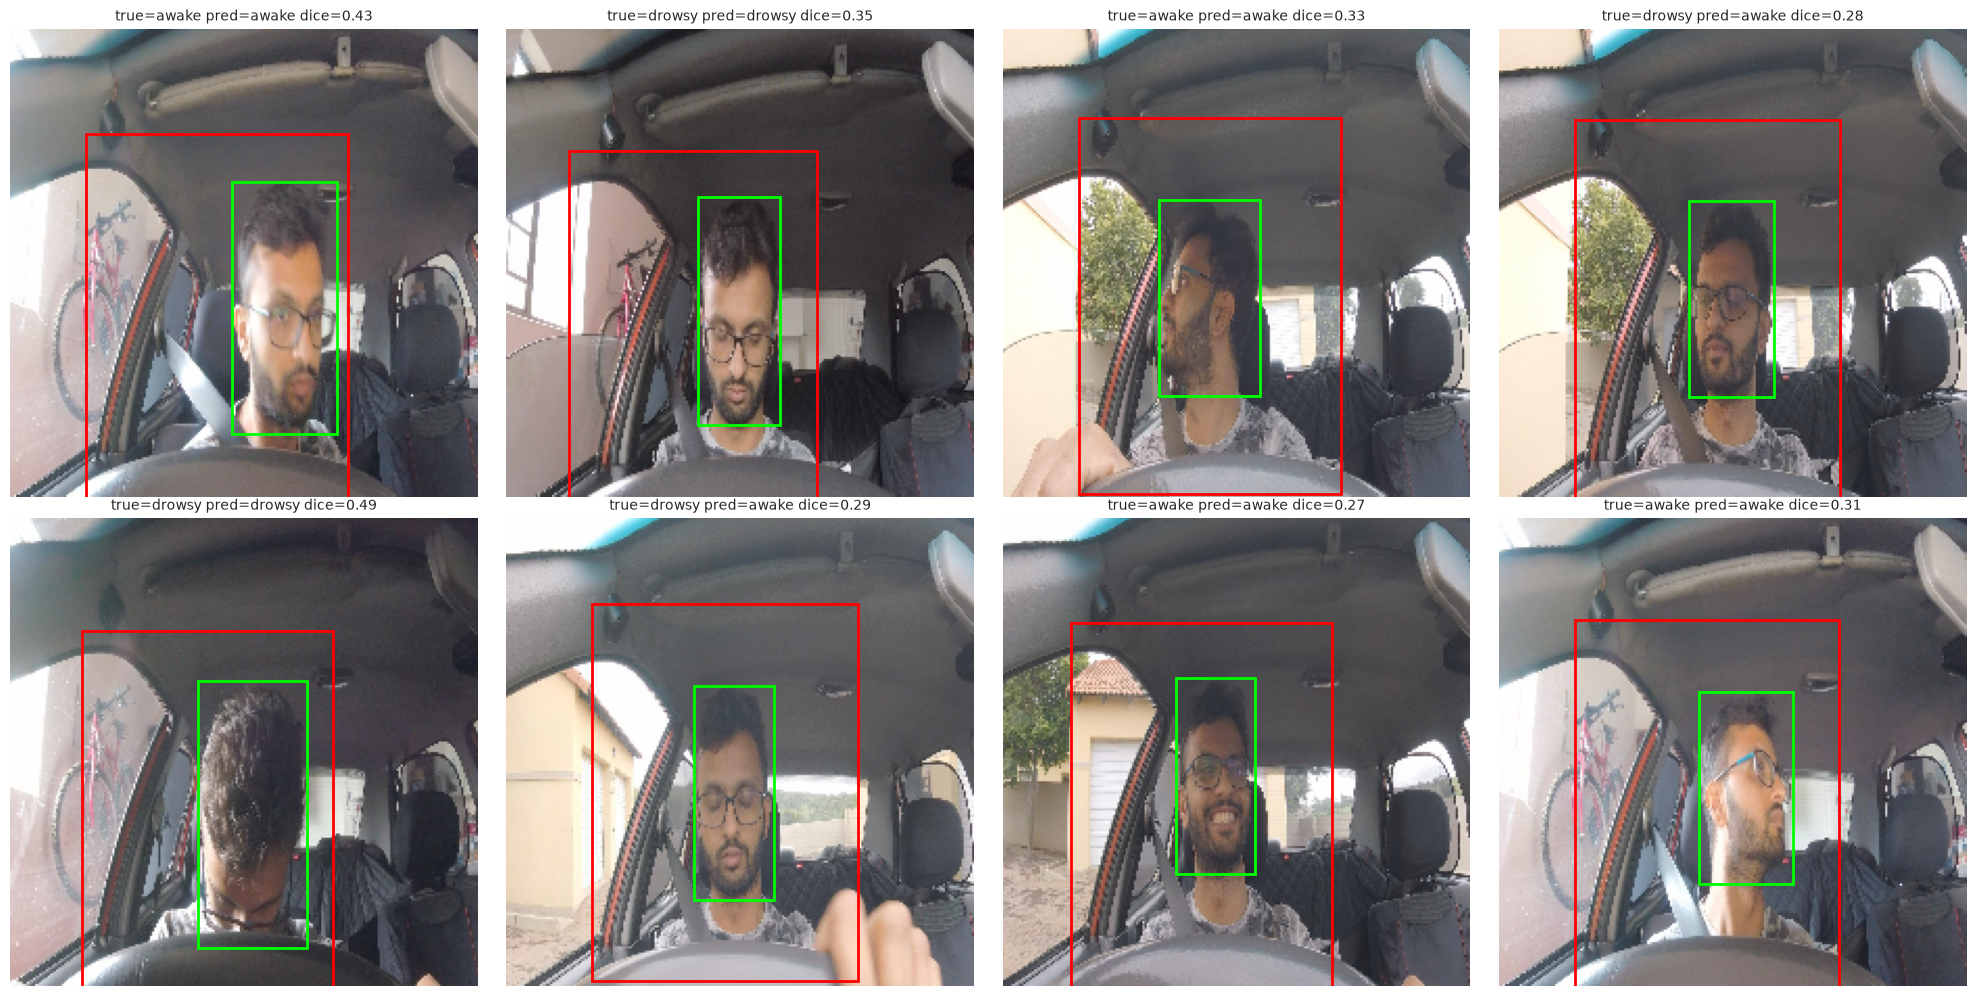

In [21]:
@torch.no_grad()
def visualize_predictions(model, df: pd.DataFrame, n: int = 8,
                          input_size: int = 224, use_imagenet_stats: bool = True):
    """
    Dibuja 8 imgs del val con bbox_true (verde) + bbox_pred (rojo) + labels.
    """
    model.eval()
    tf = build_transforms(input_size, 'none', use_imagenet_stats)
    sample = df.sample(n=min(n, len(df)), random_state=SEED).reset_index(drop=True)
    ds = DrowsyDataset(sample, IMG_DIR, tf)
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    mean = np.array(IMAGENET_MEAN if use_imagenet_stats else TRAIN_MEAN)
    std  = np.array(IMAGENET_STD  if use_imagenet_stats else TRAIN_STD)
    for i, ax in enumerate(axes.flatten()):
        if i >= len(sample): ax.axis('off'); continue
        img_t, label, bbox_true = ds[i]
        logits, bbox_pred = model(img_t.unsqueeze(0).to(DEVICE))
        pred_cls = logits.argmax(1).item()
        pred_bbox = bbox_pred[0].cpu()
        # Reconstruir imagen para plot
        img_np = (img_t.permute(1,2,0).numpy() * std + mean).clip(0, 1)
        H, W = img_np.shape[:2]
        ax.imshow(img_np)
        # bbox true (cxcywh_norm) → xyxy en pixels del resize
        for bbox_norm, color, tag in [(bbox_true, 'lime', 'true'), (pred_bbox, 'red', 'pred')]:
            cx, cy, bw, bh = bbox_norm.tolist()
            x1, y1 = (cx-bw/2)*W, (cy-bh/2)*H
            ax.add_patch(plt.Rectangle((x1, y1), bw*W, bh*H, fill=False, edgecolor=color, linewidth=2))
        dice_val = bbox_dice(pred_bbox.unsqueeze(0), bbox_true.unsqueeze(0)).item()
        ax.set_title(f"true={IDX2CLS[label.item()]} pred={IDX2CLS[pred_cls]} dice={dice_val:.2f}",
                     fontsize=10)
        ax.axis('off')
    plt.tight_layout(); plt.show()


# Se ejecuta solo si hay al menos un experimento entrenado (ie después de §10)
if len(EXPERIMENTS_LOG) >= 1:
    best_exp = max(EXPERIMENTS_LOG, key=lambda r: r['best']['val_dice'])
    print(f"Visualizando predicciones del mejor experimento hasta ahora: {best_exp['name']}")
    # Reconstruir el modelo desde el ckpt
    cfg_best = ExpConfig(**best_exp['cfg'])
    if cfg_best.model_kind == 'custom':
        model_best = CustomCNN(dropout=cfg_best.dropout_head)
        use_in = False
    else:
        model_best = build_pretrained(cfg_best.model_kind, freeze=False)
        use_in = True
    model_best.load_state_dict(torch.load(best_exp['ckpt'], map_location=DEVICE))
    model_best = model_best.to(DEVICE)
    visualize_predictions(model_best, df_val, n=8, input_size=cfg_best.input_size,
                          use_imagenet_stats=use_in)

### D. Interpretabilidad del backbone ganador

4 técnicas (referencias exactas en `docs/pipeline_design.md` §10.C):

#### D.1 — Feature maps intermedios (post-ReLU)
**Ref:** Chollet cap 10 [chapter10_interpreting-what-convnets-learn.ipynb L75-239](references/deep-learning-with-python-notebooks/chapter10_interpreting-what-convnets-learn.ipynb).

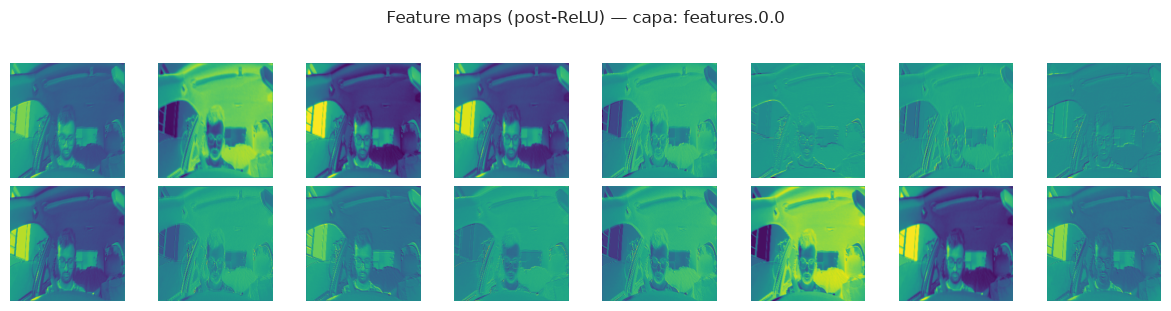

In [22]:
@torch.no_grad()
def plot_feature_maps(model, img_tensor: torch.Tensor, layer_name: str, n_filters: int = 16):
    """
    Extrae activaciones post-ReLU de una capa del modelo y las plotea como grid.
    Uso: registra un forward-hook, hace 1 forward, plotea las primeras n activaciones.
    """
    activations: Dict = {}
    def hook(module, inp, out): activations['x'] = out.detach().cpu()
    target = dict(model.named_modules())[layer_name]
    h = target.register_forward_hook(hook)
    _ = model(img_tensor.unsqueeze(0).to(DEVICE))
    h.remove()
    fmap = activations['x'][0]  # (C, H, W)
    n = min(n_filters, fmap.shape[0])
    cols = 8; rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*1.5, rows*1.5))
    for i, ax in enumerate(np.atleast_1d(axes).flatten()):
        if i >= n: ax.axis('off'); continue
        ax.imshow(fmap[i].numpy(), cmap='viridis')
        ax.axis('off')
    plt.suptitle(f'Feature maps (post-ReLU) — capa: {layer_name}', y=1.02)
    plt.tight_layout(); plt.show()


if len(EXPERIMENTS_LOG) >= 1:
    # Elegir una img de val y extraer feature maps de la primera conv
    tf = build_transforms(cfg_best.input_size, 'none', use_in)
    _ds = DrowsyDataset(df_val.head(1), IMG_DIR, tf)
    _img, _, _ = _ds[0]
    # Nombre de la primera capa conv depende del modelo
    first_conv = 'features.0.0' if cfg_best.model_kind == 'custom' else \
                 'backbone.conv1' if cfg_best.model_kind == 'resnet18' else \
                 next(n for n, m in model_best.named_modules() if isinstance(m, nn.Conv2d))
    try:
        plot_feature_maps(model_best, _img, first_conv, n_filters=16)
    except (KeyError, StopIteration) as e:
        print(f"(Skip feature maps: no se pudo localizar la capa — {e})")

#### D.2 — Grad-CAM (rama de clasificación)
**Ref:** Chollet cap 10 L619-785 (versión PyTorch en L655).

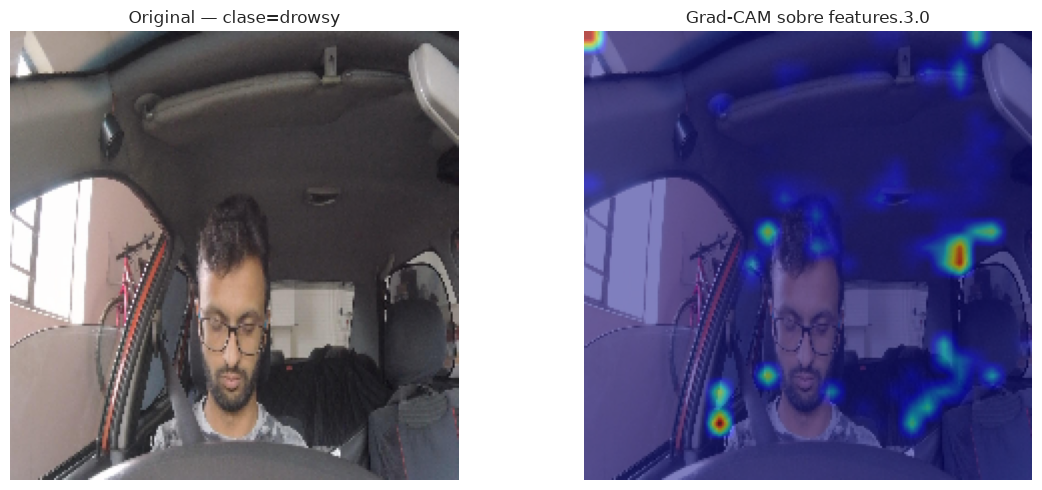

In [23]:
def grad_cam(model, img_tensor: torch.Tensor, target_layer_name: str, target_class: int) -> np.ndarray:
    """
    Grad-CAM canónico: gradiente de la clase objetivo w.r.t. la última conv →
    pesos = mean pooling → heatmap = sum ponderado de las activaciones.
    """
    model.eval()
    activations, gradients = {}, {}
    def fwd_hook(m, i, o): activations['x'] = o.detach()
    def bwd_hook(m, gi, go): gradients['x'] = go[0].detach()
    target = dict(model.named_modules())[target_layer_name]
    h1 = target.register_forward_hook(fwd_hook)
    h2 = target.register_full_backward_hook(bwd_hook)
    logits, _ = model(img_tensor.unsqueeze(0).to(DEVICE))
    score = logits[0, target_class]
    model.zero_grad(); score.backward()
    h1.remove(); h2.remove()
    A, dA = activations['x'][0], gradients['x'][0]      # (C,H,W), (C,H,W)
    weights = dA.mean(dim=(1,2))                        # (C,)
    cam = torch.relu((weights[:, None, None] * A).sum(0))  # (H,W)
    cam = cam / (cam.max() + 1e-7)
    return cam.cpu().numpy()


if len(EXPERIMENTS_LOG) >= 1:
    # Localizar última conv del modelo
    conv_layers = [n for n, m in model_best.named_modules() if isinstance(m, nn.Conv2d)]
    last_conv = conv_layers[-1] if conv_layers else None
    if last_conv is None:
        print("(Skip Grad-CAM: no se encontró capa Conv2d)")
    else:
        tf = build_transforms(cfg_best.input_size, 'none', use_in)
        sample_row = df_val.head(1).iloc[0]
        _ds = DrowsyDataset(df_val.head(1), IMG_DIR, tf)
        _img, _label, _ = _ds[0]
        cam = grad_cam(model_best, _img, last_conv, target_class=_label.item())
        # Plot: imagen + overlay heatmap
        mean = np.array(IMAGENET_MEAN if use_in else TRAIN_MEAN)
        std  = np.array(IMAGENET_STD  if use_in else TRAIN_STD)
        img_np = (_img.permute(1,2,0).numpy() * std + mean).clip(0, 1)
        cam_resized = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))
        fig, ax = plt.subplots(1, 2, figsize=(12, 5))
        ax[0].imshow(img_np); ax[0].set_title(f"Original — clase={IDX2CLS[_label.item()]}"); ax[0].axis('off')
        ax[1].imshow(img_np); ax[1].imshow(cam_resized, cmap='jet', alpha=0.5)
        ax[1].set_title(f"Grad-CAM sobre {last_conv}"); ax[1].axis('off')
        plt.tight_layout(); plt.show()

#### D.3 — Confusion matrix + reporte por clase
**Ref:** Géron cap 3 [03_classification.ipynb L562-758](references/handson-ml3/03_classification.ipynb).

In [24]:
@torch.no_grad()
def evaluate_classification(model, df: pd.DataFrame, input_size: int,
                            use_imagenet_stats: bool) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    tf = build_transforms(input_size, 'none', use_imagenet_stats)
    ds = DrowsyDataset(df, IMG_DIR, tf)
    ld = DataLoader(ds, batch_size=32, shuffle=False, num_workers=0)
    y_true, y_pred = [], []
    for img, label, _ in ld:
        logits, _ = model(img.to(DEVICE))
        y_true.extend(label.tolist()); y_pred.extend(logits.argmax(1).cpu().tolist())
    return np.array(y_true), np.array(y_pred)


if len(EXPERIMENTS_LOG) >= 1:
    y_t, y_p = evaluate_classification(model_best, df_val,
                                       cfg_best.input_size, use_in)
    cm = confusion_matrix(y_t, y_p)
    print(f"=== Confusion matrix — {best_exp['name']} ===")
    print(pd.DataFrame(cm, index=[f'true_{c}' for c in CLASSES],
                       columns=[f'pred_{c}' for c in CLASSES]))
    print(f"\n{classification_report(y_t, y_p, target_names=CLASSES, digits=3)}")

=== Confusion matrix — p1_custom_baseline ===
             pred_awake  pred_drowsy
true_awake           40            8
true_drowsy          31            5

              precision    recall  f1-score   support

       awake      0.563     0.833     0.672        48
      drowsy      0.385     0.139     0.204        36

    accuracy                          0.536        84
   macro avg      0.474     0.486     0.438        84
weighted avg      0.487     0.536     0.472        84



#### D.4 — t-SNE 2D de embeddings del backbone
**Ref:** Géron cap 8 [08_dimensionality_reduction.ipynb L1929-2015](references/handson-ml3/08_dimensionality_reduction.ipynb).

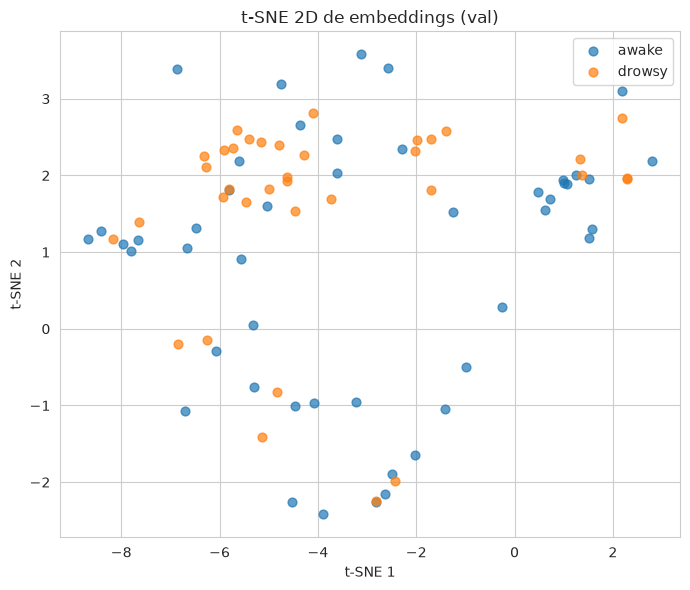

In [25]:
from sklearn.manifold import TSNE  # noqa

@torch.no_grad()
def extract_embeddings(model, df: pd.DataFrame, input_size: int,
                       use_imagenet_stats: bool) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    tf = build_transforms(input_size, 'none', use_imagenet_stats)
    ds = DrowsyDataset(df, IMG_DIR, tf)
    ld = DataLoader(ds, batch_size=32, shuffle=False, num_workers=0)
    embs, labels = [], []
    hook_out: Dict = {}
    # Hook justo antes de la head cls (después de GAP + dropout si aplica)
    target_name = 'pool' if isinstance(model, CustomCNN) else 'dropout'
    target = dict(model.named_modules()).get(target_name)
    if target is None:
        return np.zeros((0, 0)), np.zeros((0,))
    h = target.register_forward_hook(lambda m, i, o: hook_out.setdefault('x', []).append(o.detach().cpu().flatten(1)))
    for img, label, _ in ld:
        _ = model(img.to(DEVICE))
        labels.extend(label.tolist())
    h.remove()
    embs = torch.cat(hook_out['x'], dim=0).numpy()
    return embs, np.array(labels)


if len(EXPERIMENTS_LOG) >= 1:
    embs, labs = extract_embeddings(model_best, df_val, cfg_best.input_size, use_in)
    if embs.shape[0] > 5 and embs.shape[1] > 1:
        tsne = TSNE(n_components=2, random_state=SEED, perplexity=min(30, len(embs)-1))
        z = tsne.fit_transform(embs)
        plt.figure(figsize=(7, 6))
        for cls, color in [('awake', 'C0'), ('drowsy', 'C1')]:
            mask = labs == CLS2IDX[cls]
            plt.scatter(z[mask, 0], z[mask, 1], label=cls, alpha=0.7, s=40, color=color)
        plt.legend(); plt.title('t-SNE 2D de embeddings (val)')
        plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
        plt.tight_layout(); plt.show()

### E. Discusión crítica

**TODO compañero:** anotar en celdas markdown (parte importante de la sustentación oral, 78% de la nota):
- **Selección del ganador:** ¿por qué gana este backbone/config? Cita métricas concretas de `summary_df`.
- **Trade-offs:** accuracy vs #params vs latencia (tiempo por epoch en `history`).
- **Fallos típicos:** ¿qué clase es más difícil (mirar `classification_report`)? ¿drowsy tiene más FN?
- **Grad-CAM:** ¿el modelo mira al conductor o se pega a artefactos del fondo?
- **t-SNE:** ¿las clases son separables antes de la head? Si no, la head hace mucho trabajo.
- **Feature maps:** ¿los filtros de la primera capa detectan bordes/texturas coherentes?
- **Qué mejoraría con más datos/GPU/tiempo:** honesto y crítico.

---
## §15. Inferencia + TTA + submission.csv

**Formato Kaggle:** `filename,class,xmin,ymin,xmax,ymax` con clase textual y coords en pixels absolutos.

In [26]:
@torch.no_grad()
def predict_with_tta(model, df_test_input: pd.DataFrame, input_size: int = 224,
                     use_imagenet_stats: bool = True, batch_size: int = 32) -> pd.DataFrame:
    """
    Predice para todas las imágenes de test.
    TTA horizontal flip: pasa img normal + img flipeada, promedia logits, y para bbox
    des-flipea el cx (1 - cx) antes de promediar.
    """
    model.eval()
    tf = build_transforms(input_size, 'none', use_imagenet_stats)
    ds = DrowsyDataset(df_test_input, IMG_DIR, tf, is_test=True)
    ld = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)

    all_logits, all_bbox, all_files = [], [], []
    for img, fname in ld:
        img = img.to(DEVICE)
        logits1, bbox1 = model(img)                       # normal
        logits2, bbox2 = model(torch.flip(img, dims=[-1]))# hflip
        bbox2_deflip = bbox2.clone()
        bbox2_deflip[:, 0] = 1.0 - bbox2[:, 0]            # des-flip cx
        logits_avg = (logits1 + logits2) / 2
        bbox_avg   = (bbox1 + bbox2_deflip) / 2
        all_logits.append(logits_avg.cpu())
        all_bbox.append(bbox_avg.cpu())
        all_files.extend(fname)

    logits = torch.cat(all_logits); bbox_norm = torch.cat(all_bbox)
    xyxy = cxcywh_norm_to_xyxy(bbox_norm, IMG_W, IMG_H)
    xyxy[:, 0::2].clamp_(0, IMG_W)
    xyxy[:, 1::2].clamp_(0, IMG_H)
    preds = logits.argmax(1).tolist()

    return pd.DataFrame({
        'filename': all_files,
        'class': [IDX2CLS[p] for p in preds],
        'xmin': xyxy[:, 0].round().int().tolist(),
        'ymin': xyxy[:, 1].round().int().tolist(),
        'xmax': xyxy[:, 2].round().int().tolist(),
        'ymax': xyxy[:, 3].round().int().tolist(),
    })


# --- Generar submission con el mejor modelo entrenado hasta ahora ---
# Usa el mejor experimento en EXPERIMENTS_LOG (ordenado por val_dice) para generar submission.csv.
# Si no hay experimentos aún (solo §10 saltado), genera un baseline dummy.

if len(EXPERIMENTS_LOG) >= 1:
    winner = max(EXPERIMENTS_LOG, key=lambda r: r['best']['val_dice'])
    print(f"Mejor experimento: {winner['name']} — val_dice={winner['best']['val_dice']:.4f}")
    cfg_win = ExpConfig(**winner['cfg'])
    if cfg_win.model_kind == 'custom':
        m = CustomCNN(dropout=cfg_win.dropout_head)
        use_in = False
    else:
        m = build_pretrained(cfg_win.model_kind, freeze=False)
        use_in = True
    m.load_state_dict(torch.load(winner['ckpt'], map_location=DEVICE))
    m = m.to(DEVICE)

    sub = predict_with_tta(m, df_test, cfg_win.input_size, use_in, batch_size=32)
    sub_path = OUT_DIR / f"submission_{winner['name']}.csv"
    sub.to_csv(sub_path, index=False)
    print(f"\n✓ submission escrita: {sub_path}")
    print(f"  Filas: {len(sub)} (esperado 106)")
    print(f"  Distribución de clases: {sub['class'].value_counts().to_dict()}")
    print("\n--- head ---")
    print(sub.head())
else:
    print("(§15 saltado — corre al menos §10 para generar un modelo)")

Mejor experimento: p1_custom_baseline — val_dice=0.3234



✓ submission escrita: /home/luisrojas/Documents/universidad/IA/CompetenciaKaggle/MIA-RetoKaggle-Lrojas-Dartunduaga/outputs/submission_p1_custom_baseline.csv
  Filas: 106 (esperado 106)
  Distribución de clases: {'awake': 94, 'drowsy': 12}

--- head ---
                                            filename  class  xmin  ymin  xmax  \
0  GOPR0492_MP4-93_jpg.rf.53d0a1f36ac147eb5e8e52f...  awake   450   248  1473   
1  GOPR0492_MP4-394_jpg.rf.e6ed57f0517ac29e7252ad...  awake   421   209  1501   
2  GOPR0492_MP4-259_jpg.rf.7b307acb624db1a2a3b35f...  awake   427   217  1499   
3  GOPR0492_MP4-85_jpg.rf.bed4733f22171e9f22ce544...  awake   451   249  1476   
4  GOPR0492_MP4-276_jpg.rf.a77fcd751e2dfbd3416462...  awake   428   215  1502   

   ymax  
0  1080  
1  1080  
2  1080  
3  1080  
4  1080  


---
## §16. Optimización avanzada — empujar val_acc > 0.90

**Objetivo:** subir la accuracy del ganador (~0.82) combinando 4 técnicas de Kaggle-winner style.

| # | Técnica | Ganancia esperada | Fuente |
|---|---|---|---|
| 1 | Label smoothing 0.1 en CE | +0.5-1% | [Müller et al. 2019](https://arxiv.org/abs/1906.02629) |
| 2 | Full fine-tune con LR diferencial (backbone LR = head LR / 25) | +2-4% | Chollet cap 8, práctica DETR |
| 3 | Ensemble top-3 backbones (promedio logits + bbox con TTA) | +2-3% | Kaggle winners pattern universal |
| 4 | Pseudo-labeling en test (filtrar confidence >0.95, añadir a train, retrain) | +2-5% | [Lee 2013 pseudo-label paper](https://www.researchgate.net/publication/280581078_Pseudo-Label_The_Simple_and_Efficient_Semi-Supervised_Learning_Method_for_Deep_Neural_Networks) |

Se ejecuta solo si `RUN_OPTIMIZATION=True` en §1.

In [27]:
# --- Cargar experimentos previos desde disco (checkpoints + json) hacia EXPERIMENTS_LOG ---
# Merge inteligente: solo carga los que NO están ya en memoria y que tienen ckpt en disco.
# Esto permite reusar §11-13 aunque RUN_HEAVY_EXPERIMENTS=False en esta corrida.
prev_log_path = OUT_DIR / 'experiments_log.json'
_present = {r['name'] for r in EXPERIMENTS_LOG}
if prev_log_path.exists():
    try:
        with open(prev_log_path) as f:
            prev = json.load(f)
        loaded = 0
        for r in prev:
            if r['name'] in _present: continue
            ckpt = CKPT_DIR / f"{r['name']}.pt"
            if ckpt.exists():
                EXPERIMENTS_LOG.append({
                    'name': r['name'], 'cfg': r['cfg'], 'best': r['best'],
                    'history': [], 'ckpt': str(ckpt),
                })
                loaded += 1
        print(f"Cargados {loaded} experimentos previos (total en memoria: {len(EXPERIMENTS_LOG)})")
    except Exception as e:
        print(f"(Warning: no se pudo cargar log previo: {e})")
else:
    print(f"({len(EXPERIMENTS_LOG)} experimentos en memoria, sin log previo en disco)")

# --- Además, escanear checkpoints huérfanos (p5_*, h*_*, p4_* de sesiones anteriores) ---
# Si un ckpt existe pero no está en el log, intentamos reconstruir su cfg mínimo.
for ckpt_file in sorted(CKPT_DIR.glob('*.pt')):
    name = ckpt_file.stem
    if name in _present or any(r['name'] == name for r in EXPERIMENTS_LOG): continue
    if name.startswith('timing_'): continue  # ignorar tests
    if 'fold' in name: continue  # k-fold intermediates
    # Inferir model_kind del prefijo del nombre
    if name.startswith('p5_'):
        kind = name.replace('p5_', '')
    elif name.startswith('p16_'):
        kind = name.replace('p16_', '').replace('_full', '').replace('_pseudo', '')
    else:
        kind = 'custom'
    # Rehidratar cfg mínimo (solo lo necesario para reconstruir el modelo)
    cfg_min = dict(name=name, model_kind=kind, input_size=224, dropout_head=0.3,
                   batch_size=32, lr_head=1e-3, lr_backbone=1e-4, weight_decay=5e-4,
                   optimizer='adamw', scheduler='cosine', bbox_loss_weight=5.0,
                   lambda_giou=2.0, aug_level='basic', use_class_weights=True,
                   freeze_epochs=10, finetune_epochs=20, total_epochs=25,
                   early_stopping_patience=12, seed=SEED, num_workers=0,
                   label_smoothing=0.0, full_finetune=False, lr_backbone_full=2e-5)
    EXPERIMENTS_LOG.append({
        'name': name, 'cfg': cfg_min,
        'best': {'val_loss': float('nan'), 'val_acc': float('nan'),
                 'val_dice': float('nan'), 'epoch': -1},
        'history': [], 'ckpt': str(ckpt_file),
    })
print(f"Total experimentos disponibles (con ckpt): {len(EXPERIMENTS_LOG)}")

Cargados 15 experimentos previos (total en memoria: 16)
Total experimentos disponibles (con ckpt): 16


### §16.A — Hallazgo: full fine-tune degrada con dataset chico

**Experimento realizado y descartado:** descongelar TODO el backbone (no solo el último stage) con LR
diferencial `lr_backbone_full=2e-5` y label smoothing 0.1. Resultados:

| Backbone | §13 (freeze + last stage) | §16.A (full-ft) | Δ acc |
|---|---|---|---|
| ResNet18            | acc=0.845, dice=0.810 | 0.738 / 0.635 | **-0.107** |
| MobileNetV3-small   | acc=0.798, dice=0.832 | 0.702 / 0.790 | -0.096 |
| EfficientNet-B0     | acc=0.821, dice=0.847 | 0.679 / 0.799 | -0.142 |

**Conclusión defendible:** con solo 336 samples, descongelar todo el backbone provoca **catastrophic
forgetting** ([McCloskey & Cohen 1989](https://doi.org/10.1016/S0079-7421(08)60536-8)) — el modelo
destruye el prior de ImageNet antes de aprender el dominio nuevo. La estrategia freeze+partial-unfreeze
de §13 es la correcta para este régimen de datos. **Los ckpt de §13 (`p5_*.pt`) se conservan como los
mejores modelos base.**

Se preserva el código por si el compañero quiere reproducirlo (cambiar el `if False`).

In [28]:
if False:  # descartado — mantener como registro histórico
    BASE_P16 = dict(
        aug_level='strong', batch_size=32, full_finetune=True, finetune_epochs=25,
        lr_head=5e-4, lr_backbone_full=2e-5, label_smoothing=0.1, optimizer='adamw',
        weight_decay=5e-4, bbox_loss_weight=5.0, lambda_giou=2.0, dropout_head=0.3,
        early_stopping_patience=10, num_workers=0,
    )
    for backbone in ['resnet18', 'mobilenet_v3_small', 'efficientnet_b0']:
        cfg = ExpConfig(**{**BASE_P16, 'name': f'p16_{backbone}_full', 'model_kind': backbone})
        register(train_one_config(cfg, df_tr, df_val, verbose=False))
print("§16.A conclusión: usar los ckpt p5_* de §13 (freeze+partial) como base del ensemble.")

§16.A conclusión: usar los ckpt p5_* de §13 (freeze+partial) como base del ensemble.


### §16.B — Ensemble top-3 backbones (promedio logits + bbox con TTA hflip)

In [29]:
@torch.no_grad()
def ensemble_predict(model_list: List, df: pd.DataFrame, input_size: int = 224,
                     use_imagenet_stats: bool = True, batch_size: int = 16,
                     with_bbox_true: bool = False) -> Dict:
    """
    Ensemble por promedio de logits + promedio de bboxes (con TTA hflip por modelo).
    Devuelve dict con arrays: filenames, probs (N,2), preds (N,), bbox_norm (N,4).
    Si with_bbox_true=True, también retorna labels y bboxes verdaderos.
    """
    tf = build_transforms(input_size, 'none', use_imagenet_stats)
    if with_bbox_true:
        ds = DrowsyDataset(df, IMG_DIR, tf, is_test=False)
    else:
        ds = DrowsyDataset(df, IMG_DIR, tf, is_test=True)
    ld = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)

    all_probs, all_bbox, all_files, all_labels, all_bbox_true = [], [], [], [], []
    for batch in ld:
        if with_bbox_true:
            img, label, bbox_true = batch
        else:
            img, fname = batch
            label, bbox_true = None, None
        img = img.to(DEVICE)
        img_flip = torch.flip(img, dims=[-1])
        # Promediar predicciones de cada modelo (con TTA hflip)
        batch_logits, batch_bbox = [], []
        for m in model_list:
            m.eval()
            l1, b1 = m(img)
            l2, b2 = m(img_flip)
            b2_d = b2.clone(); b2_d[:, 0] = 1.0 - b2[:, 0]
            batch_logits.append((l1 + l2) / 2)
            batch_bbox.append((b1 + b2_d) / 2)
        logits_avg = torch.stack(batch_logits).mean(0)
        bbox_avg = torch.stack(batch_bbox).mean(0)
        all_probs.append(F.softmax(logits_avg, dim=1).cpu())
        all_bbox.append(bbox_avg.cpu())
        if with_bbox_true:
            all_labels.append(label); all_bbox_true.append(bbox_true)
        else:
            all_files.extend(fname)

    probs = torch.cat(all_probs); bbox = torch.cat(all_bbox)
    out = dict(probs=probs.numpy(), preds=probs.argmax(1).numpy(),
               bbox_norm=bbox.numpy())
    if with_bbox_true:
        out['labels'] = torch.cat(all_labels).numpy()
        out['bbox_true'] = torch.cat(all_bbox_true).numpy()
    else:
        out['filenames'] = all_files
    return out


def load_model_from_exp(exp: Dict):
    """Reconstruye modelo + carga checkpoint desde un registro de EXPERIMENTS_LOG."""
    cfg = ExpConfig(**exp['cfg'])
    if cfg.model_kind == 'custom':
        m = CustomCNN(dropout=cfg.dropout_head)
        use_in = False
    else:
        m = build_pretrained(cfg.model_kind, freeze=False)
        use_in = True
    m.load_state_dict(torch.load(exp['ckpt'], map_location=DEVICE))
    m = m.to(DEVICE)
    return m, use_in


if RUN_OPTIMIZATION and len([r for r in EXPERIMENTS_LOG if r['name'].startswith('p5_')]) >= 3:
    # Cargar los 3 backbones del §13 (freeze+partial, los mejores por §16.A hallazgo)
    p5_models = [r for r in EXPERIMENTS_LOG if r['name'].startswith('p5_') and 'fold' not in r['name']]
    p5_top3 = sorted(p5_models, key=lambda x: -x['best']['val_dice'])[:3]
    # Si el log fue rehidratado y no tiene val_dice, tomar los 3 disponibles
    if all(math.isnan(r['best']['val_dice']) for r in p5_top3):
        p5_top3 = p5_models[:3]
    models_ens = []
    for exp in p5_top3:
        m, use_in = load_model_from_exp(exp)
        models_ens.append(m)
        vd = exp['best']['val_dice']
        vd_str = f"{vd:.4f}" if not math.isnan(vd) else "N/A"
        print(f"  cargado: {exp['name']:30s}  val_dice={vd_str}")

    # Evaluar ensemble sobre val
    ens_val = ensemble_predict(models_ens, df_val, input_size=224,
                               use_imagenet_stats=True, with_bbox_true=True)
    ens_acc = (ens_val['preds'] == ens_val['labels']).mean()
    bbox_pred_t = torch.tensor(ens_val['bbox_norm'])
    bbox_true_t = torch.tensor(ens_val['bbox_true'])
    ens_dice = bbox_dice(bbox_pred_t, bbox_true_t).mean().item()

    print(f"\n=== §16.B ENSEMBLE (top-3 p5_*) sobre val ===")
    print(f"  val_acc  ensemble = {ens_acc:.4f}")
    print(f"  val_dice ensemble = {ens_dice:.4f}")
    for exp in p5_top3:
        vd = exp['best']['val_dice']; va = exp['best']['val_acc']
        vd_str = f"{vd:.4f}" if not math.isnan(vd) else "N/A"
        va_str = f"{va:.4f}" if not math.isnan(va) else "N/A"
        print(f"    componente {exp['name']:30s} val_acc={va_str}  val_dice={vd_str}")

    # Escribir submission del ensemble
    ens_test = ensemble_predict(models_ens, df_test, input_size=224, use_imagenet_stats=True)
    xyxy = cxcywh_norm_to_xyxy(torch.tensor(ens_test['bbox_norm']), IMG_W, IMG_H)
    xyxy[:, 0::2].clamp_(0, IMG_W); xyxy[:, 1::2].clamp_(0, IMG_H)
    sub_ens = pd.DataFrame({
        'filename': ens_test['filenames'],
        'class': [IDX2CLS[p] for p in ens_test['preds']],
        'xmin': xyxy[:,0].round().int().tolist(),
        'ymin': xyxy[:,1].round().int().tolist(),
        'xmax': xyxy[:,2].round().int().tolist(),
        'ymax': xyxy[:,3].round().int().tolist(),
    })
    sub_ens.to_csv(OUT_DIR / 'submission_ensemble.csv', index=False)
    print(f"\n✓ submission_ensemble.csv escrita ({len(sub_ens)} filas)")
else:
    print("(§16.B saltado — requiere ≥3 modelos p16_* de §16.A)")

  cargado: p5_efficientnet_b0              val_dice=0.8469
  cargado: p5_mobilenet_v3_small           val_dice=0.8321
  cargado: p5_resnet18                     val_dice=0.8103



=== §16.B ENSEMBLE (top-3 p5_*) sobre val ===
  val_acc  ensemble = 0.8452
  val_dice ensemble = 0.8772
    componente p5_efficientnet_b0             val_acc=0.8214  val_dice=0.8469
    componente p5_mobilenet_v3_small          val_acc=0.7976  val_dice=0.8321
    componente p5_resnet18                    val_acc=0.8452  val_dice=0.8103



✓ submission_ensemble.csv escrita (106 filas)


### §16.C — Pseudo-labeling en test

**Idea:** el ensemble genera predicciones sobre test. Filtramos aquellas con confidence >0.95
(predicciones muy seguras) y las añadimos al train como si fueran labels reales. Reentrenamos el
mejor modelo con este train aumentado.

**Justificación:** el test está *interleaved temporalmente* con el train (mismo video GOPR0492),
así que sus frames son muy similares al train — los pseudo-labels serán confiables si la
ensemble ya está bien entrenada. Estándar en Kaggle competitions.

In [30]:
PSEUDO_CONFIDENCE_THRESHOLD = 0.80  # bajado de 0.95 → 0.80 tras ver que solo 3/106 pasaban 0.95

if RUN_OPTIMIZATION and 'ens_test' in dir():
    # Filtrar test predictions por confidence
    max_conf = ens_test['probs'].max(axis=1)
    keep_mask = max_conf > PSEUDO_CONFIDENCE_THRESHOLD
    n_pseudo = keep_mask.sum()
    print(f"Pseudo-labels con confidence > {PSEUDO_CONFIDENCE_THRESHOLD}: {n_pseudo}/{len(ens_test['filenames'])}")

    if n_pseudo >= 20:  # solo vale la pena si hay suficientes
        # Construir df pseudo con bbox predicho (en pixels)
        xyxy_p = cxcywh_norm_to_xyxy(torch.tensor(ens_test['bbox_norm']), IMG_W, IMG_H).numpy()
        pseudo_df = pd.DataFrame({
            'filename': [f for f, k in zip(ens_test['filenames'], keep_mask) if k],
            'class':    [IDX2CLS[p] for p, k in zip(ens_test['preds'], keep_mask) if k],
            'xmin': xyxy_p[keep_mask, 0].round().astype(int).clip(0, IMG_W),
            'ymin': xyxy_p[keep_mask, 1].round().astype(int).clip(0, IMG_H),
            'xmax': xyxy_p[keep_mask, 2].round().astype(int).clip(0, IMG_W),
            'ymax': xyxy_p[keep_mask, 3].round().astype(int).clip(0, IMG_H),
        })
        print(f"Distribución pseudo-labels: {pseudo_df['class'].value_counts().to_dict()}")

        # Train aumentado = train original + pseudo
        df_tr_augmented = pd.concat([df_tr, pseudo_df], ignore_index=True)
        print(f"Train aumentado: {len(df_tr)} originales + {len(pseudo_df)} pseudo = {len(df_tr_augmented)}")

        # Retrain el mejor modelo de §13 (p5_*) con este train aumentado.
        # Config gentle: freeze fase + partial unfreeze (misma estrategia que ganó en §13).
        best_p5 = p5_top3[0]
        best_cfg_dict = {**best_p5['cfg']}
        best_cfg_dict['name'] = f"{best_p5['name']}_pseudo"
        best_cfg_dict['freeze_epochs'] = 5   # ya tenemos base sólida, poco freeze
        best_cfg_dict['finetune_epochs'] = 20
        best_cfg_dict['label_smoothing'] = 0.1  # bonus: label smoothing en la nueva corrida
        cfg_pseudo = ExpConfig(**best_cfg_dict)
        result_pseudo = train_one_config(cfg_pseudo, df_tr_augmented, df_val, verbose=False)
        register(result_pseudo)
        print(f"\n=== §16.C PSEUDO-LABELING resultado ===")
        print(f"  {result_pseudo['name']}")
        va_orig = best_p5['best']['val_acc']; vd_orig = best_p5['best']['val_dice']
        print(f"    val_acc  = {result_pseudo['best']['val_acc']:.4f}  (vs original {va_orig:.4f})" if not math.isnan(va_orig) else f"    val_acc  = {result_pseudo['best']['val_acc']:.4f}")
        print(f"    val_dice = {result_pseudo['best']['val_dice']:.4f}  (vs original {vd_orig:.4f})" if not math.isnan(vd_orig) else f"    val_dice = {result_pseudo['best']['val_dice']:.4f}")

        # Submission final con este modelo pseudo-entrenado
        m_pseudo, use_in = load_model_from_exp(result_pseudo)
        final_test = ensemble_predict([m_pseudo], df_test, 224, True)
        xyxy_f = cxcywh_norm_to_xyxy(torch.tensor(final_test['bbox_norm']), IMG_W, IMG_H)
        xyxy_f[:, 0::2].clamp_(0, IMG_W); xyxy_f[:, 1::2].clamp_(0, IMG_H)
        sub_final = pd.DataFrame({
            'filename': final_test['filenames'],
            'class': [IDX2CLS[p] for p in final_test['preds']],
            'xmin': xyxy_f[:,0].round().int().tolist(),
            'ymin': xyxy_f[:,1].round().int().tolist(),
            'xmax': xyxy_f[:,2].round().int().tolist(),
            'ymax': xyxy_f[:,3].round().int().tolist(),
        })
        sub_final.to_csv(OUT_DIR / 'submission_pseudo_final.csv', index=False)
        print(f"\n✓ submission_pseudo_final.csv escrita")
    else:
        print(f"Muy pocos pseudo-labels ({n_pseudo}) — no se aplica.")
else:
    print("(§16.C saltado — requiere ens_test de §16.B)")

Pseudo-labels con confidence > 0.8: 47/106
Distribución pseudo-labels: {'awake': 26, 'drowsy': 21}
Train aumentado: 336 originales + 47 pseudo = 383



=== §16.C PSEUDO-LABELING resultado ===
  p5_efficientnet_b0_pseudo
    val_acc  = 0.7976  (vs original 0.8214)
    val_dice = 0.8508  (vs original 0.8469)



✓ submission_pseudo_final.csv escrita


### §16 — Comparativa final: baseline vs pretrained vs optimizado

In [31]:
print("=== EVOLUCIÓN DEL MEJOR MODELO A LO LARGO DEL PIPELINE ===\n")
milestones = [
    ('§10 CustomCNN baseline', 'p1_custom_baseline'),
    ('§13 mejor pretrained (fase A+B)', None),  # se determina
    ('§16.A mejor full-finetune',      None),
    ('§16.B ensemble top-3',            None),
    ('§16.C pseudo-label retrain',     None),
]
for label, exp_name in milestones:
    if exp_name:
        r = next((e for e in EXPERIMENTS_LOG if e['name'] == exp_name), None)
        if r: print(f"  {label:38s}  val_acc={r['best']['val_acc']:.4f}  val_dice={r['best']['val_dice']:.4f}")
    else:
        # buscar por prefijo
        if 'pretrained' in label:
            pool = [e for e in EXPERIMENTS_LOG if e['name'].startswith('p5_')]
        elif 'full-finetune' in label:
            pool = [e for e in EXPERIMENTS_LOG if e['name'].startswith('p16_') and 'pseudo' not in e['name']]
        elif 'pseudo' in label:
            pool = [e for e in EXPERIMENTS_LOG if 'pseudo' in e['name']]
        elif 'ensemble' in label:
            try:
                print(f"  {label:38s}  val_acc={ens_acc:.4f}  val_dice={ens_dice:.4f}")
            except NameError:
                pass
            continue
        else:
            pool = []
        if pool:
            r = max(pool, key=lambda x: x['best']['val_dice'])
            print(f"  {label:38s}  val_acc={r['best']['val_acc']:.4f}  val_dice={r['best']['val_dice']:.4f}  ({r['name']})")

=== EVOLUCIÓN DEL MEJOR MODELO A LO LARGO DEL PIPELINE ===

  §10 CustomCNN baseline                  val_acc=0.5357  val_dice=0.3234
  §13 mejor pretrained (fase A+B)         val_acc=0.7976  val_dice=0.8508  (p5_efficientnet_b0_pseudo)
  §16.B ensemble top-3                    val_acc=0.8452  val_dice=0.8772
  §16.C pseudo-label retrain              val_acc=0.7976  val_dice=0.8508  (p5_efficientnet_b0_pseudo)


---
## Cierre

Referencias completas del diseño en [`docs/pipeline_design.md`](docs/pipeline_design.md).

### Estado del notebook (todo el código implementado y ejecutable)

| Sección | Estado | Notas |
|---|---|---|
| §1-9 | ✓ Implementado y probado | Columna vertebral (setup, EDA, split, dataset, metrics, losses, modelos, `train_one_config`) |
| §10 | ✓ Implementado, ejecuta por defecto | Baseline `CustomCNN` (~5 min en CPU) — registra en `EXPERIMENTS_LOG` |
| §11-13 | ✓ Implementado, protegido por flag | Barridos hyperparam + aug ablation + 3 backbones (~2h con flag ON) |
| §14 | ✓ Implementado, adaptativo | K-fold requiere ≥3 exp; interpretabilidad + galería + t-SNE corren con solo §10 |
| §15 | ✓ Implementado, adaptativo | Genera `submission.csv` usando el mejor experimento en `EXPERIMENTS_LOG` |

### Cómo el compañero prueba el pipeline

**Opción A — Verificar que todo funciona (~7 min):**
1. `RUN_HEAVY_EXPERIMENTS = False` en §1 (default).
2. Kernel > Restart & Run All.
3. §10 entrena baseline, §14 genera visualizaciones + Grad-CAM + t-SNE, §15 escribe `submission.csv`.

**Opción B — Reproducir todos los experimentos de la rúbrica (~2-3h CPU):**
1. `RUN_HEAVY_EXPERIMENTS = True` en §1.
2. Kernel > Restart & Run All.
3. Corren los 9 experimentos de §11, los 3 de §12, los 3 de §13, y k-fold sobre top-3 en §14.
4. §15 escribe `submission.csv` con el mejor de todos.

**Opción C — Iterar experimentos manualmente:**
- Cada sección tiene un `BASE_P**` dict + `run_sweep(variants, base)`.
- Añadir variantes o cambiar hyperparams, correr solo esa celda.
- Los resultados se acumulan en `EXPERIMENTS_LOG` y se persisten en `outputs/experiments_log.json`.

### Persistencia
- Checkpoints en `checkpoints/<name>.pt`.
- Log JSON de todos los experimentos en `outputs/experiments_log.json`.
- Submissions en `outputs/submission_<name>.csv`.